# Appendix Analysis

This notebook reproduces the data-driven appendix analyses. It keeps the reader-facing flow short: each section loads the relevant data, performs the aggregation needed for the figure, prints an inspectable summary, and writes the figure files.

Platform screenshots and qualitative case-study panels are assembled as static appendix assets; this notebook covers the quantitative plots that are generated from study data.


## Setup

The setup resolves paths in a way that works directly in Jupyter with the repository Python environment. Figure display is controlled by `SHOW_FIGURES`; set it to `False` when you do not want matplotlib to open interactive windows.


In [12]:
from pathlib import Path
import sys
import warnings
import matplotlib.pyplot as plt

# Suppress display-only warnings so notebook output stays focused on the analysis results.
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", message="This figure includes Axes that are not compatible with tight_layout")
# Clear figures left open by previous interactive runs before saving new PDFs.
plt.close("all")


def _find_repo_root():
    """Find the repository root from either Jupyter or the test runner."""
    # A notebook kernel may start from the repository root or from a nested
    # directory. Walking upward makes all data paths independent of launch site.
    start = Path.cwd().resolve()
    for candidate in (start, *start.parents):
        if (candidate / "pyproject.toml").exists() and (candidate / "analyze").exists():
            return candidate
    raise RuntimeError("Could not locate repository root.")


def _data_path(*candidates):
    """Return the first existing data path among repository-relative aliases."""
    for candidate in candidates:
        path = Path(candidate)
        if not path.is_absolute():
            path = REPO_ROOT / path
        if path.exists():
            return path
    checked = ", ".join(str(c) for c in candidates)
    raise FileNotFoundError(f"None of these data paths exist: {checked}")


REPO_ROOT = _find_repo_root()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

FIGURES_DIR = REPO_ROOT / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
SHOW_FIGURES = True

print("Repository:", ".")
print("Figures:", "figures")


Repository: .
Figures: figures


In [13]:
import pandas as pd

from analyze.config import (
    EXPERIMENT_COLOR,
    CONTROL_COLOR,
    MATH_HW1_PROBLEMS,
    MATH_HW2_PROBLEMS,
    MATH_SCORE_FILE,
    MATH_SCORE_MAP,
    PRESURVEY_FILE,
    PYTHON_SCORE_FILE,
    VALIDUSER_FILE,
)
from analyze.config.paths import CAPTEST_SCORE_FILE
from analyze.core import (
    load_capability_scores,
    load_homework_scores,
    load_presurvey_data,
    load_valid_users,
    merge_presurvey_to_df,
    prepare_covariates,
)
import analyze.behavior.adoption as adoption
import analyze.behavior.assignment as assignment_behavior
import analyze.llm.evaluation as llm_eval
import analyze.stats.feature_screening as feature_screening
import analyze.survey.test_quality as test_quality
import analyze.visualization.appendix_plots as appendix_plots
import analyze.visualization.inequality_plots as inequality_plots

appendix_plots.set_nature_style()


## User Study Evaluation

This section summarizes post-task ratings about task difficulty, time sufficiency, review helpfulness, and assistant usability. The raw Chinese survey responses are first mapped to ordered Likert scores, then the figure shows course-level means with 90% and 95% confidence intervals.



Loading valid users...
  Loaded 81 Python users and 237 Math users
    Python - Treatment: 54, Control: 27
    Math - Treatment: 158, Control: 79
Saved plot to: appendix-test-quality-likert-python-math.pdf


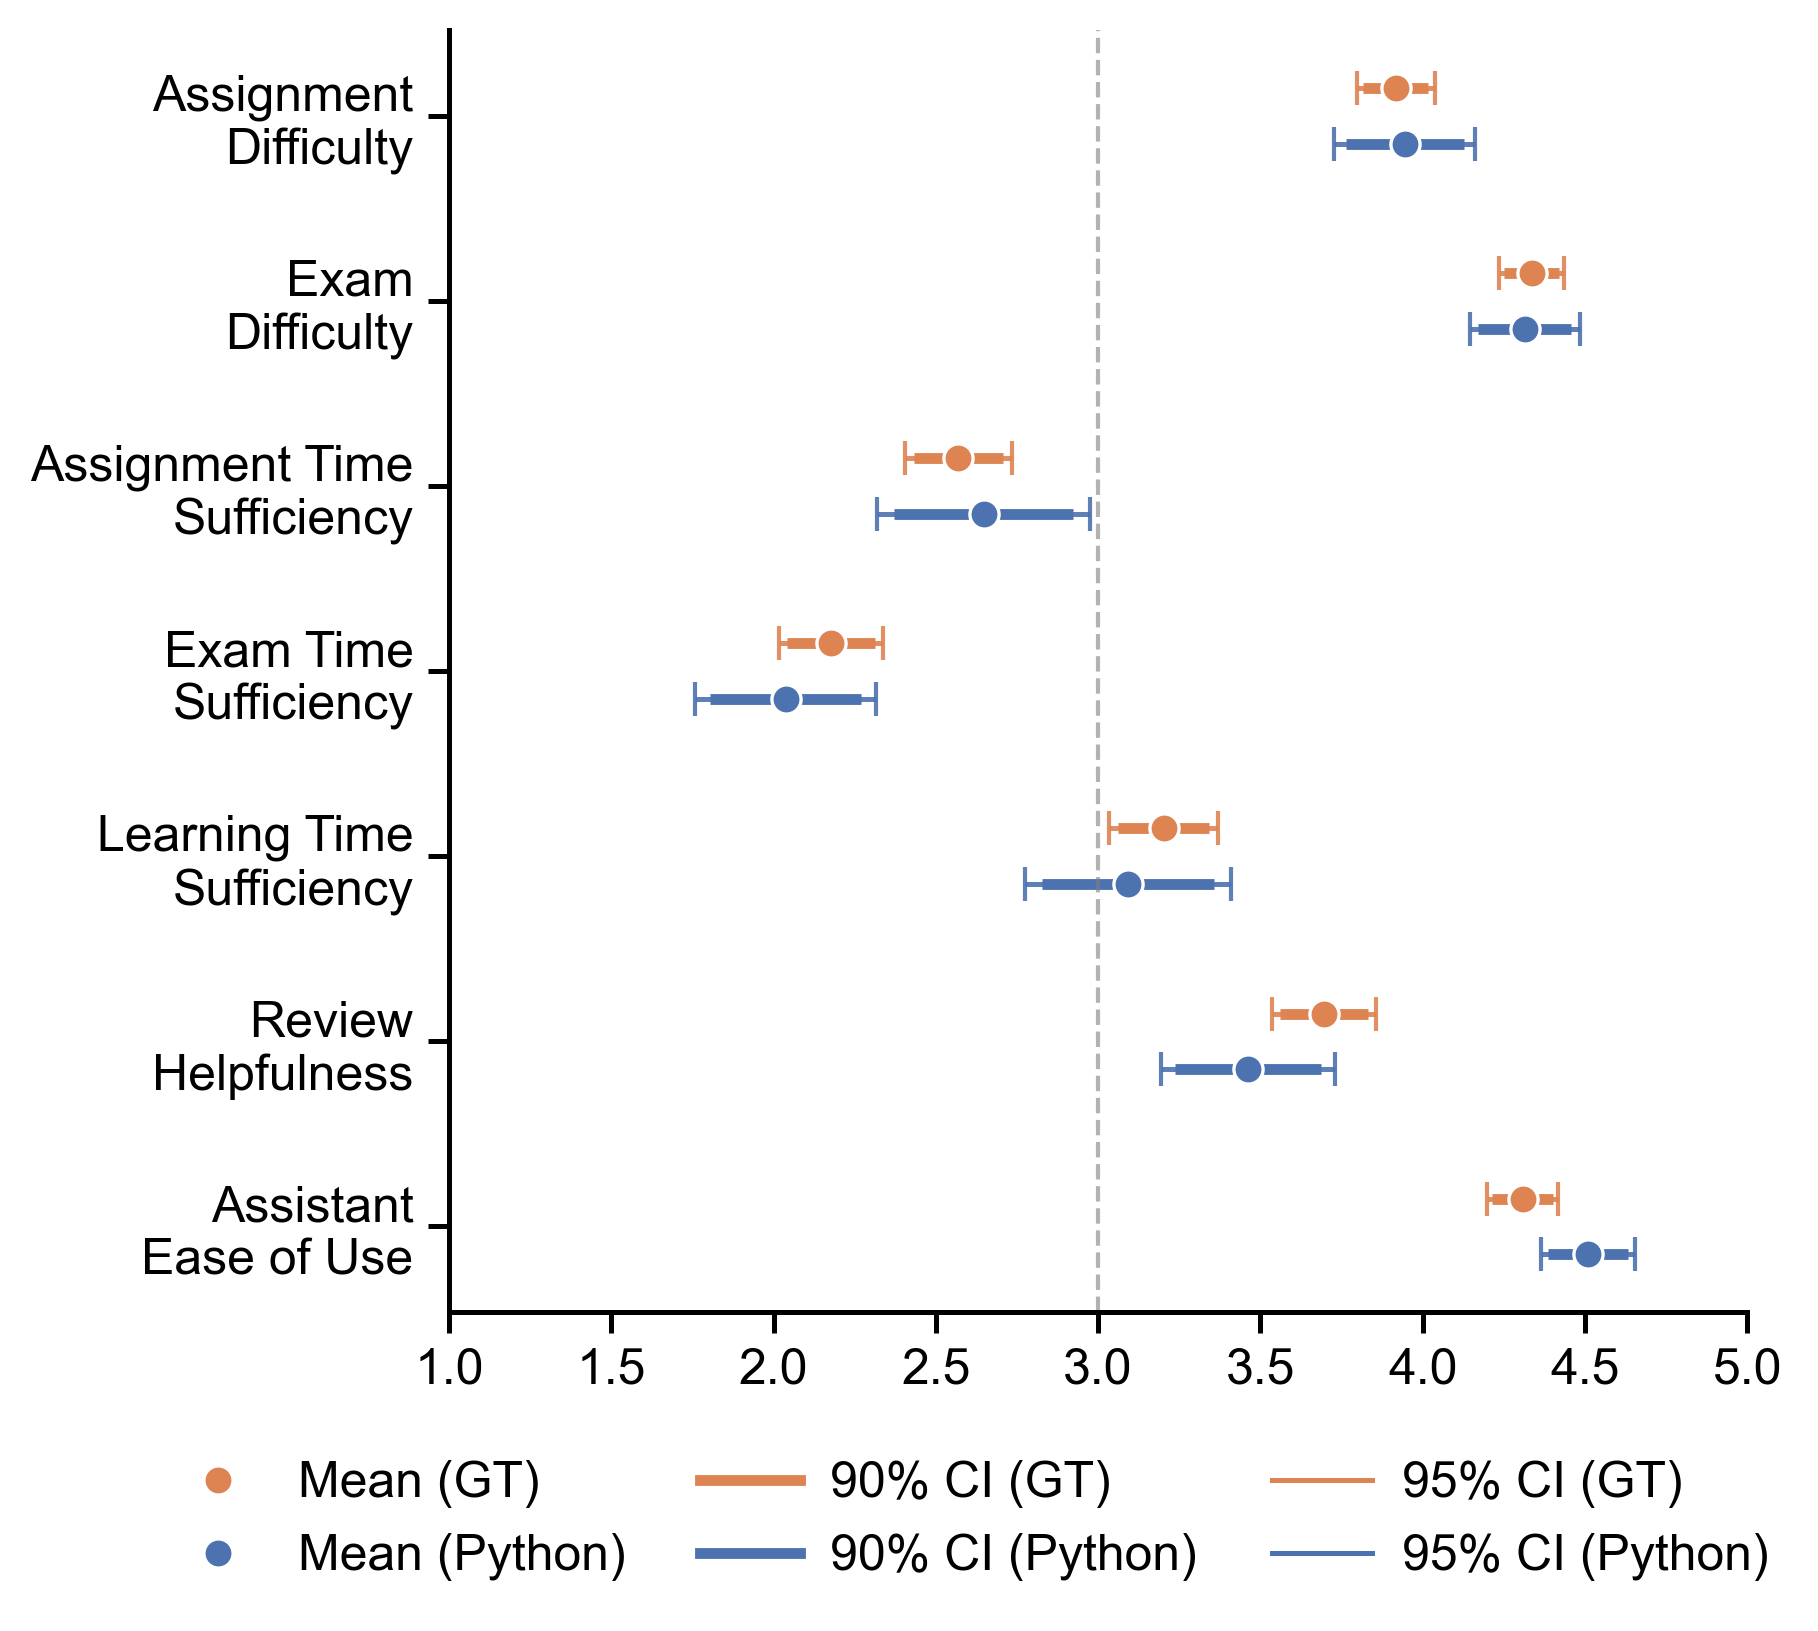

course                      item  mean  ci90  ci95   n
python            HW1 Difficulty 3.944 0.181 0.216  54
python            HW2 Difficulty 4.315 0.143 0.170  54
python      HW1 Time Sufficiency 2.648 0.276 0.328  54
python      HW2 Time Sufficiency 2.037 0.234 0.279  54
python Learning Time Sufficiency 3.093 0.265 0.316  54
python        Review Helpfulness 3.463 0.225 0.268  54
python     Assistant Ease of Use 4.509 0.122 0.146  53
  math            HW1 Difficulty 3.918 0.100 0.119 158
  math            HW2 Difficulty 4.335 0.084 0.101 158
  math      HW1 Time Sufficiency 2.570 0.138 0.165 158
  math      HW2 Time Sufficiency 2.177 0.134 0.160 158
  math Learning Time Sufficiency 3.203 0.141 0.168 158
  math        Review Helpfulness 3.696 0.135 0.161 158
  math     Assistant Ease of Use 4.308 0.093 0.111 156


In [14]:
# Load only experimental users because these ratings evaluate the assistant-enabled study experience.
df_test_quality = test_quality.load_postsurvey_data(include_control=False)
df_test_quality = test_quality.map_test_quality_likert(df_test_quality)

test_quality_items = [
    "HW1 Difficulty",
    "HW2 Difficulty",
    "HW1 Time Sufficiency",
    "HW2 Time Sufficiency",
    "Learning Time Sufficiency",
    "Review Helpfulness",
    "Assistant Ease of Use",
]

fig, _ax, test_quality_summary = appendix_plots.plot_likert_point_ci_by_course(
    dataframe=df_test_quality,
    items=test_quality_items,
    title="Test Quality Evaluation",
    course_colors={"python": "#4C72B0", "math": "#DD8452"},
    xlim=(1, 5),
)

# Keep the legacy filename and also write the appendix-paper filename.
appendix_plots.save_and_maybe_show(
    fig,
    FIGURES_DIR / "appendix-test-quality-likert-python-math.pdf",
    show=SHOW_FIGURES,
)
print(test_quality_summary.round(3).to_string(index=False))


## Learner-Profile Feature Screening

This section explains how the background variables were screened before focusing on University Ranking and Prior Knowledge. A random forest ranks encoded presurvey and prior-knowledge features by predictive importance for exam score, while univariate standardized regressions show the direction and statistical strength of each feature's association.



Loading presurvey data...
  Loaded presurvey data for 318 users

Loading valid users...
  Loaded 81 Python users and 237 Math users
    Python - Treatment: 54, Control: 27
    Math - Treatment: 158, Control: 79

Loading capability scores...
  Loaded captest for 80 Python users and 237 Math users

Loading homework scores...
  Loaded homework scores for 81 Python users and 237 Math users

Merging presurvey data for python...
  Merged presurvey data for 81 python users

Merging presurvey data for math...
  Merged presurvey data for 237 math users

Preparing covariates for python...
  Major classification: {'CS': 36, 'EE': 16, 'Other Engineering': 15, 'Math & Stat': 6, 'Natural Science': 3, 'Business': 2, 'Humanities': 2, 'Applied Science': 1}
  Prepared covariates for 81 python users

Preparing covariates for math...
  Major classification: {'Humanities': 55, 'CS': 48, 'Other Engineering': 40, 'EE': 35, 'Business': 19, 'Unknown': 15, 'Math & Stat': 14, 'Applied Science': 6, 'Natural Scie

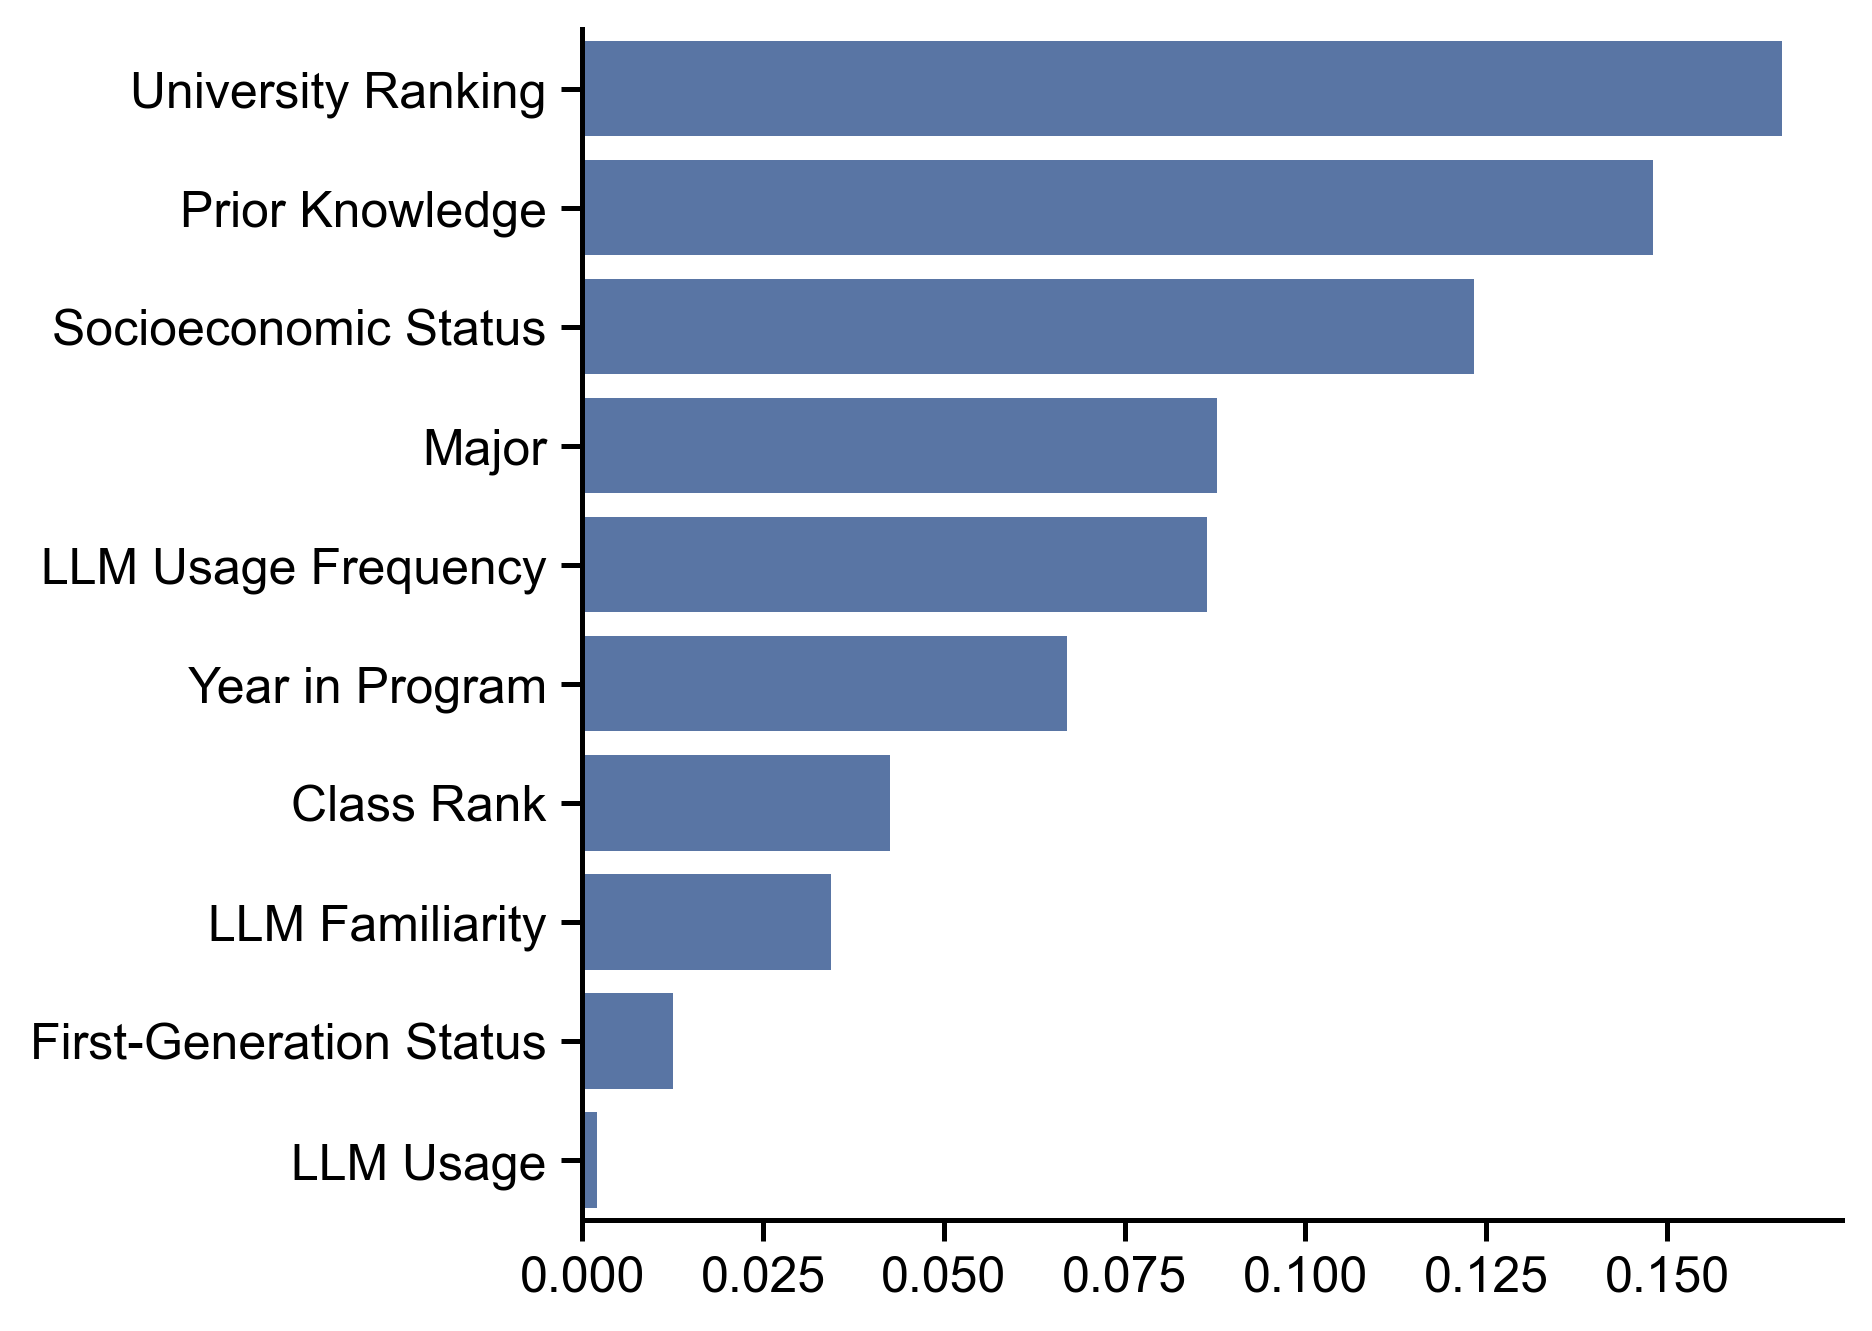

,feature_display,importance
0,University Ranking,0.1659
1,Prior Knowledge,0.1480
2,Socioeconomic Status,0.1233
3,Major,0.0878
4,LLM Usage Frequency,0.0864
5,Year in Program,0.0670
6,Class Rank,0.0426
7,LLM Familiarity,0.0345
8,First-Generation Status,0.0126
9,LLM Usage,0.0021


In [15]:
# The combined model z-scores exam scores within course before fitting, so feature
# importance is not dominated by scale differences between Python and Game Theory.
try:
    combined_importance = feature_screening.compute_feature_importance(
        course_type="combined",
        random_state=42,
        n_splits=5,
        n_estimators=300,
        max_depth=6,
        min_samples_leaf=5,
    )
except ImportError as exc:
    # The original analysis uses SHAP. If SHAP is unavailable, skip this figure
    # instead of substituting a different importance method.
    print("Feature importance skipped:", exc)
    combined_importance = pd.DataFrame(columns=["feature", "feature_display", "importance"])
else:
    appendix_plots.plot_feature_importance(
        combined_importance,
        FIGURES_DIR / "appendix-feature-importance-combined.pdf",
        show=SHOW_FIGURES,
    )

combined_importance[["feature_display", "importance"]].head(10).round(4)


Loading presurvey data...
  Loaded presurvey data for 318 users

Loading valid users...
  Loaded 81 Python users and 237 Math users
    Python - Treatment: 54, Control: 27
    Math - Treatment: 158, Control: 79

Loading capability scores...
  Loaded captest for 80 Python users and 237 Math users

Loading homework scores...
  Loaded homework scores for 81 Python users and 237 Math users

Merging presurvey data for python...
  Merged presurvey data for 81 python users

Preparing covariates for python...
  Major classification: {'CS': 36, 'EE': 16, 'Other Engineering': 15, 'Math & Stat': 6, 'Natural Science': 3, 'Business': 2, 'Humanities': 2, 'Applied Science': 1}
  Prepared covariates for 81 python users
[python] Using univariate regressions for p-values (n=68, k=10).

[python] Directional coefficients (standardized features):
        feature_display      coef  p_value direction
        Prior Knowledge  1.441423 0.005627  positive
                  Major  1.175921 0.025335  positive
  

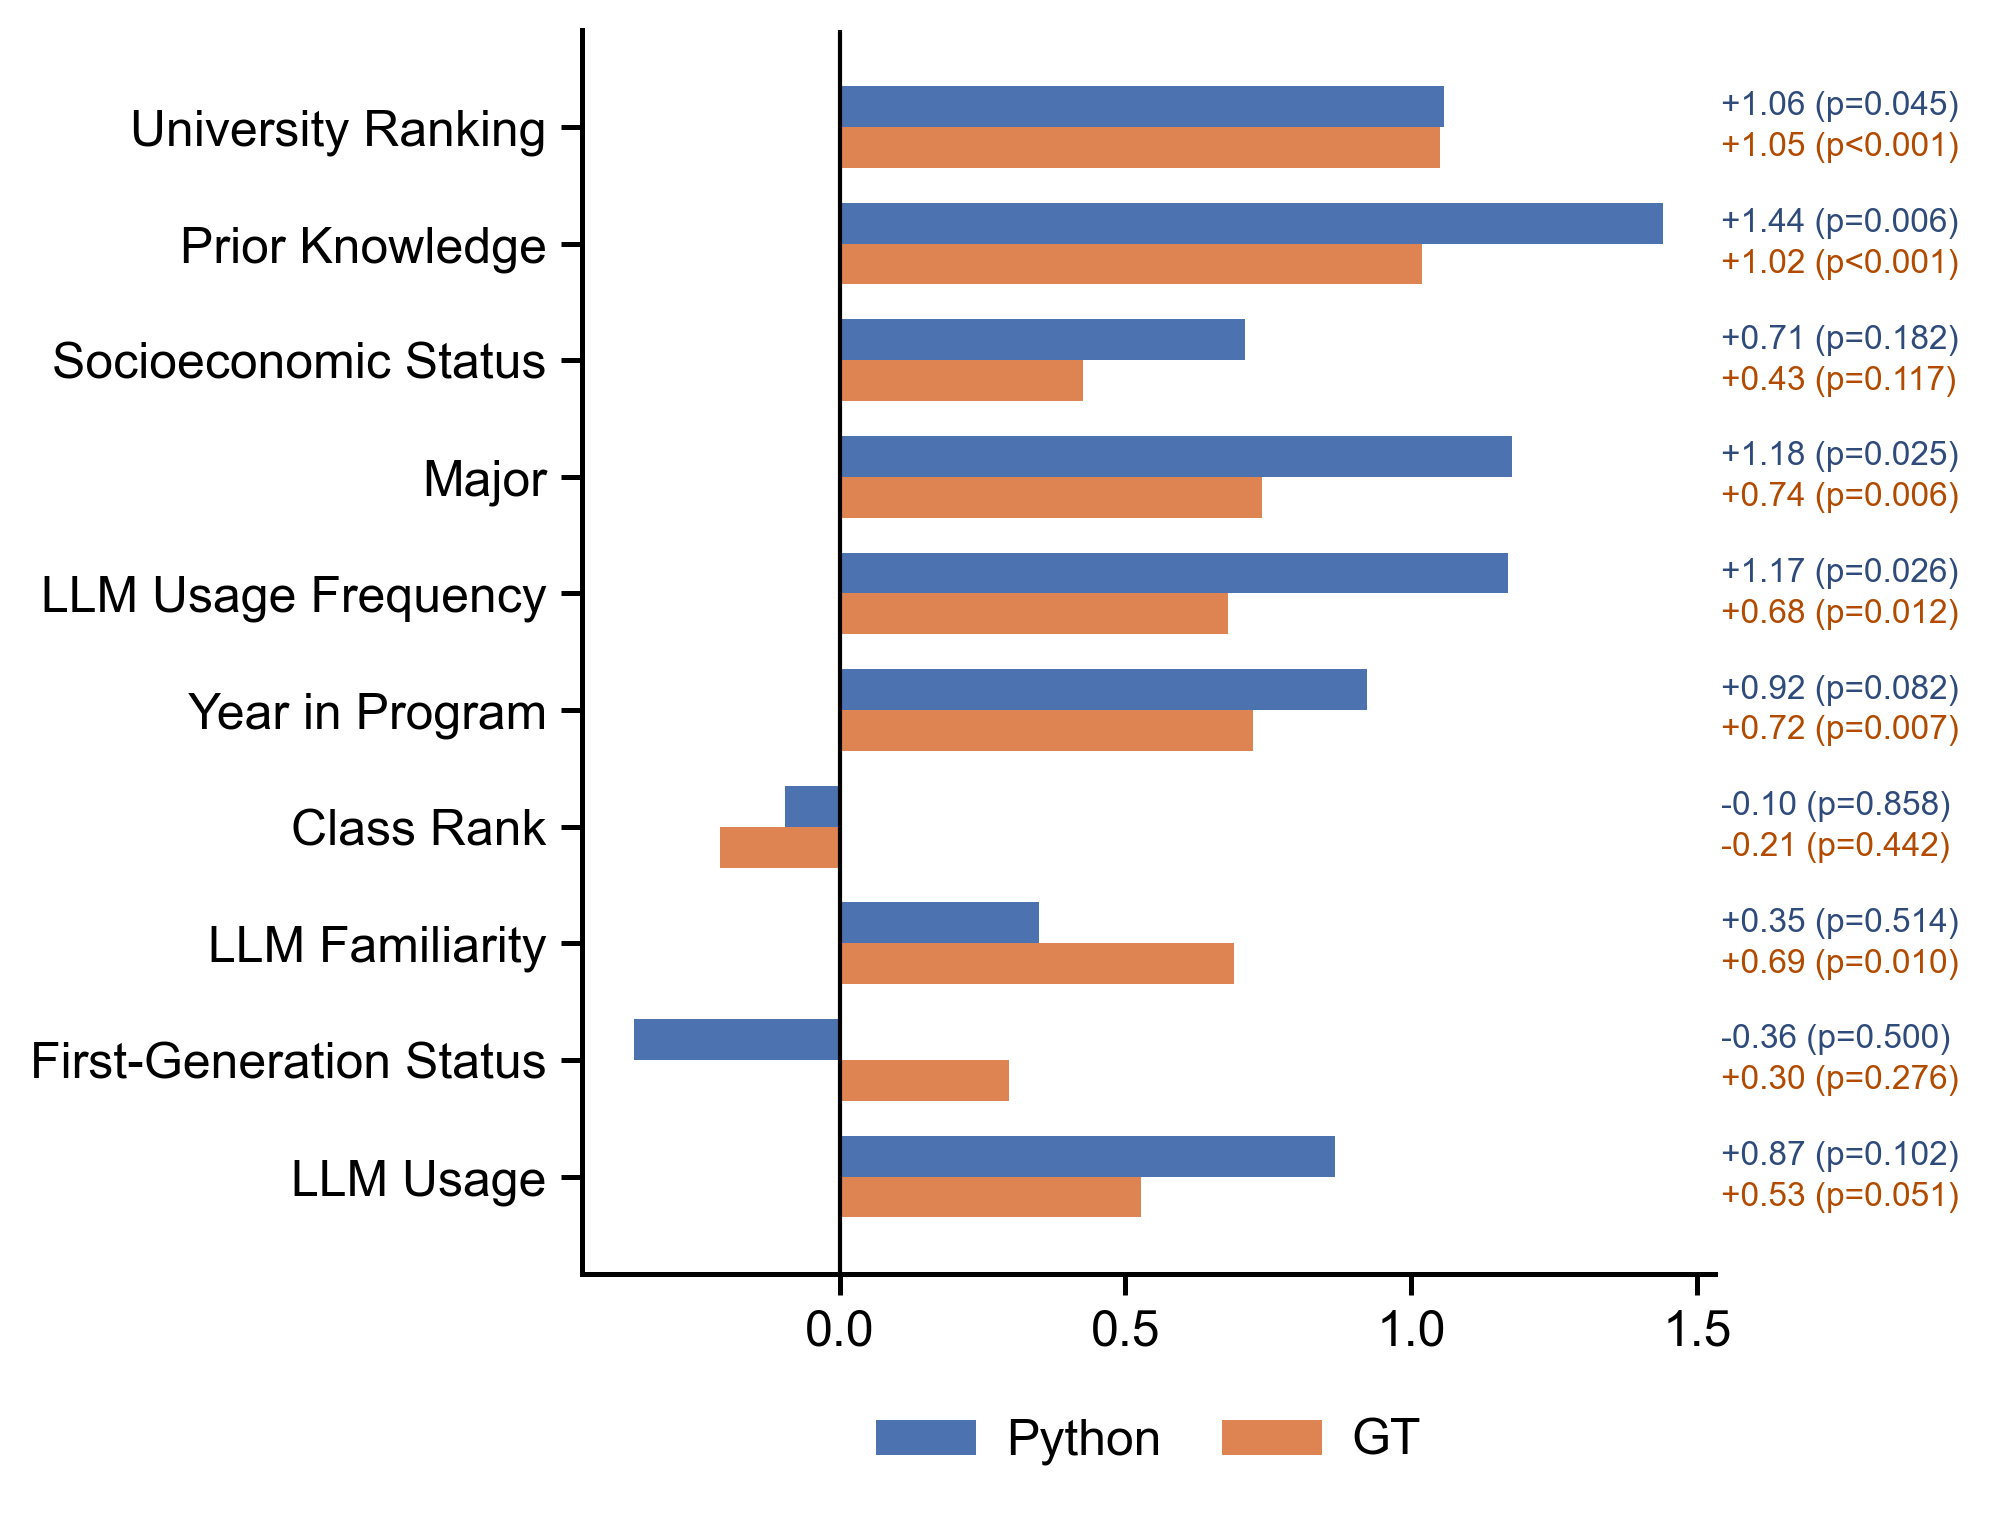

,course,feature_display,coef,p_value,direction
0,python,Prior Knowledge,1.4414,0.0056,positive
1,python,Major,1.1759,0.0253,positive
2,python,LLM Usage Frequency,1.1696,0.0262,positive
3,python,University Ranking,1.0570,0.0452,positive
4,python,Year in Program,0.9224,0.0817,positive
5,python,LLM Usage,0.8669,0.1022,positive
6,python,Socioeconomic Status,0.7098,0.1824,positive
7,python,LLM Familiarity,0.3494,0.5137,positive
8,python,Class Rank,-0.0958,0.8582,negative
9,python,First-Generation Status,-0.3608,0.5001,negative


In [16]:
# Directional regressions are run separately by course. Standardizing each
# predictor makes coefficient signs and magnitudes comparable across variables.
python_directional = feature_screening.run_feature_directional_coeffs(course_type="python")
math_directional = feature_screening.run_feature_directional_coeffs(course_type="math")

feature_order = combined_importance["feature"].tolist()
if not feature_order:
    # Use a stable display order when the SHAP-based ordering is unavailable.
    feature_order = [
        "university_cat", "capability_cat", "major_num", "grade_num",
        "class_ranking_num", "first_gen_num", "economic_status_num",
        "gpt_usage_num", "gpt_frequency_num", "gpt_familiarity_num",
    ]
appendix_plots.plot_directional_coeffs_combined(
    python_df=python_directional,
    math_df=math_directional,
    feature_order=feature_order,
    output_path=FIGURES_DIR / "appendix-feature-direction-python-math.pdf",
    show=SHOW_FIGURES,
)

pd.concat(
    [python_directional.assign(course="python"), math_directional.assign(course="math")],
    ignore_index=True,
)[["course", "feature_display", "coef", "p_value", "direction"]].round(4).head(20)


## Assignment Score by Behavior Group

This section compares first-assignment scores between the Control group and Experimental students grouped by their observed assistant-use behavior. The processing first builds HW1 score tables, then maps each experimental student to a behavior category from their A1 interaction records. The plots show the assignment-score distributions and pairwise tests against Control, which helps separate raw assignment performance from the later exam-score analyses.



Loading presurvey data...
  Loaded presurvey data for 318 users

Loading valid users...
  Loaded 81 Python users and 237 Math users
    Python - Treatment: 54, Control: 27
    Math - Treatment: 158, Control: 79

Loading capability scores...
  Loaded captest for 80 Python users and 237 Math users

Loading homework scores...
  Loaded homework scores for 81 Python users and 237 Math users

Merging presurvey data for python...
  Merged presurvey data for 81 python users

Merging presurvey data for math...
  Merged presurvey data for 237 math users

Preparing covariates for python...
  Major classification: {'CS': 36, 'EE': 16, 'Other Engineering': 15, 'Math & Stat': 6, 'Natural Science': 3, 'Business': 2, 'Humanities': 2, 'Applied Science': 1}
  Prepared covariates for 81 python users

Preparing covariates for math...
  Major classification: {'Humanities': 55, 'CS': 48, 'Other Engineering': 40, 'EE': 35, 'Business': 19, 'Unknown': 15, 'Math & Stat': 14, 'Applied Science': 6, 'Natural Scie

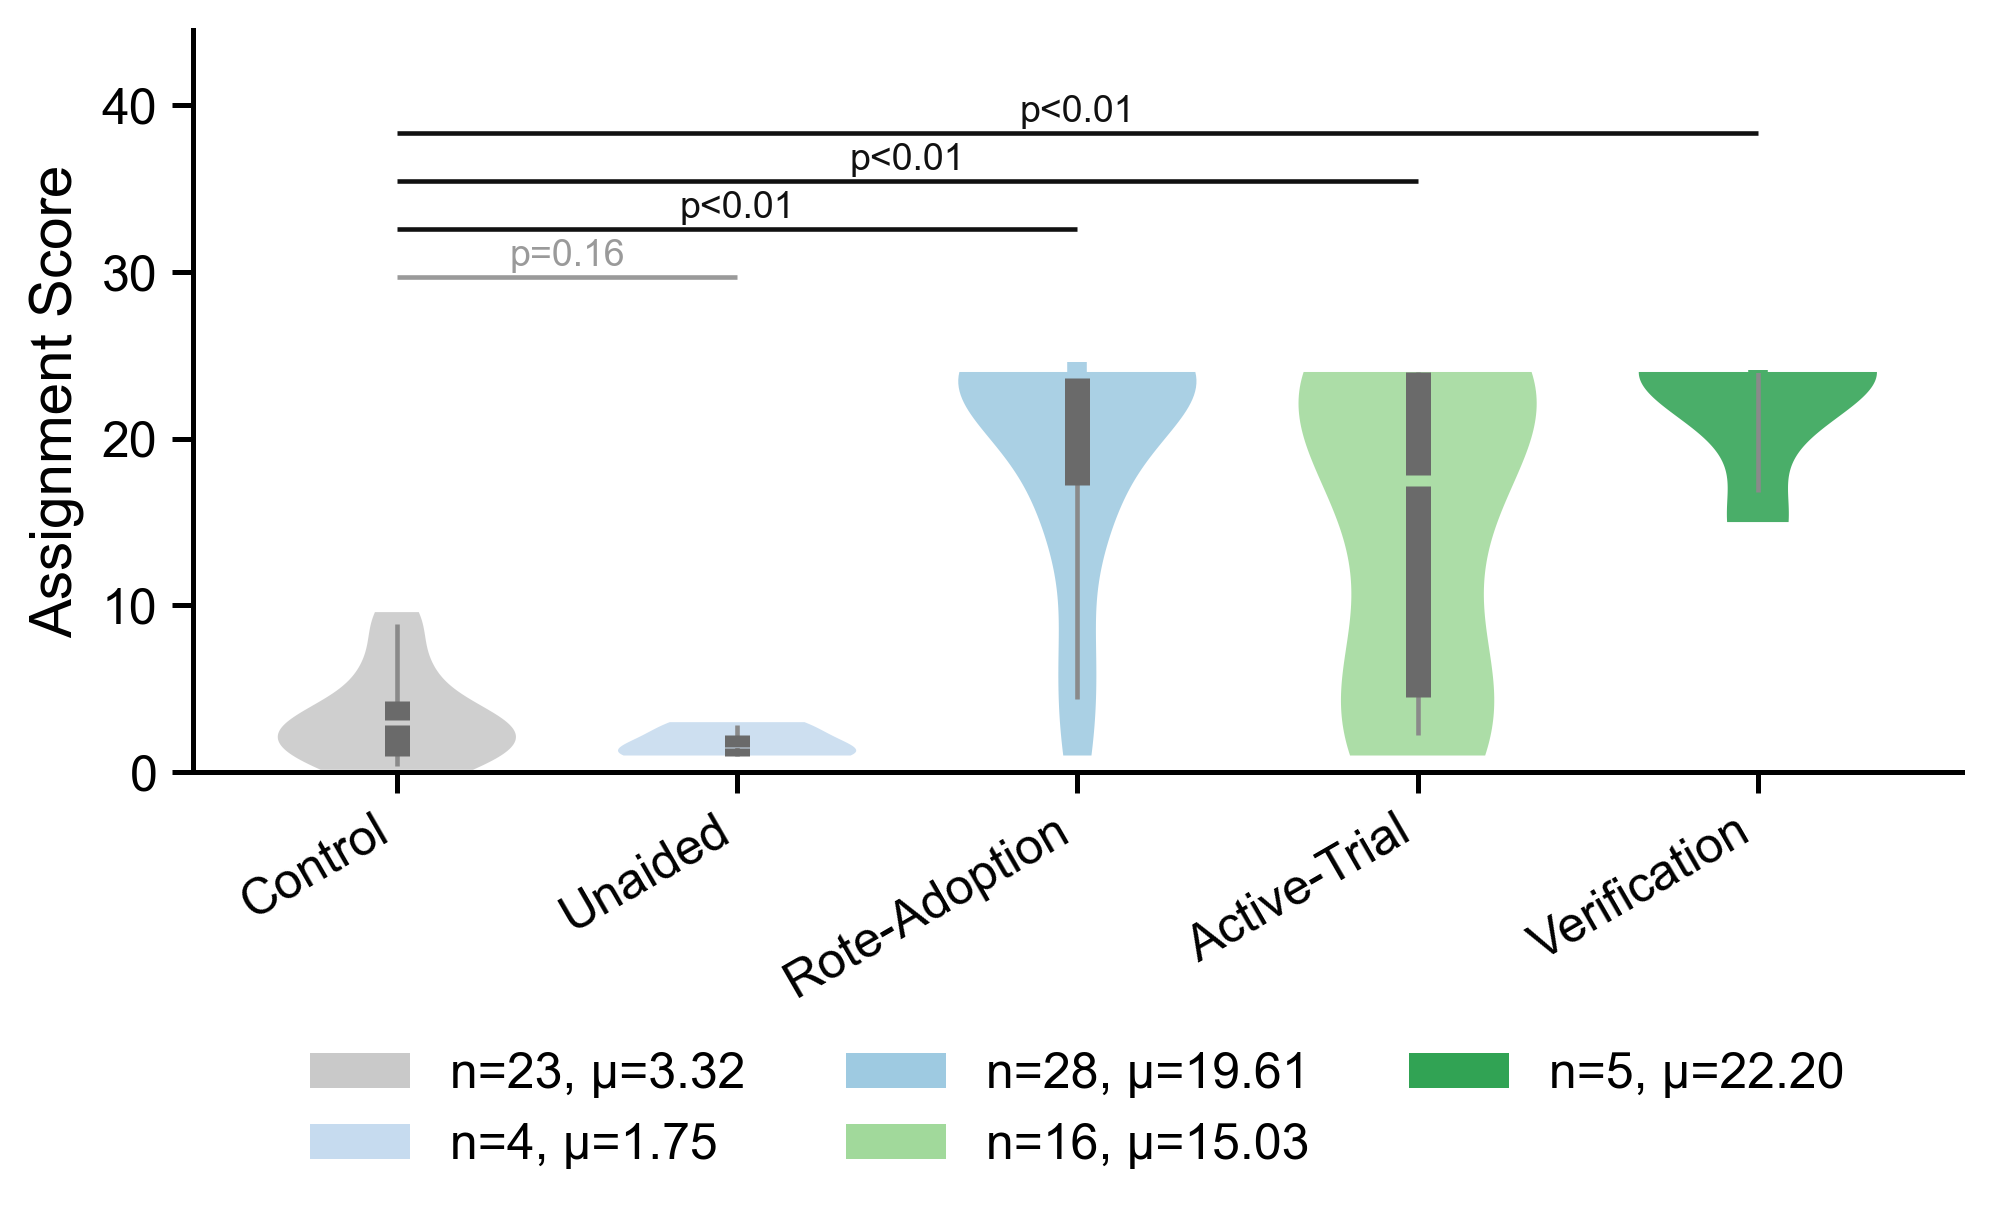


Control vs Experiment (behavior groups) hypothesis tests (raw p-values):
  Control: n=79 mean=5.924 median=5.000
  Unaided: n=33 mean=6.371 median=5.875
  Rote-Adoption: n=50 mean=9.090 median=9.875
  Active-Trial: n=43 mean=8.192 median=8.000
  Error-Correction: n=24 mean=8.078 median=7.938
  Verification: n=7 mean=8.518 median=6.875

  Kruskal-Wallis across groups: H=27.5924, p=4.37225e-05 (k=6)

  Pairwise Brunner-Munzel vs Control (two-sided, raw p-values):
group	n_ctrl	n_grp	p_brunner_munzel	p_perm_fallback
Unaided	79	33	0.207669	NA
Rote-Adoption	79	50	8.30453e-06	NA
Active-Trial	79	43	0.000719838	NA
Error-Correction	79	24	0.000262866	NA
Verification	79	7	0.0212938	NA
Saved figure: a1_math_hw1_control_vs_exp_behavior.pdf


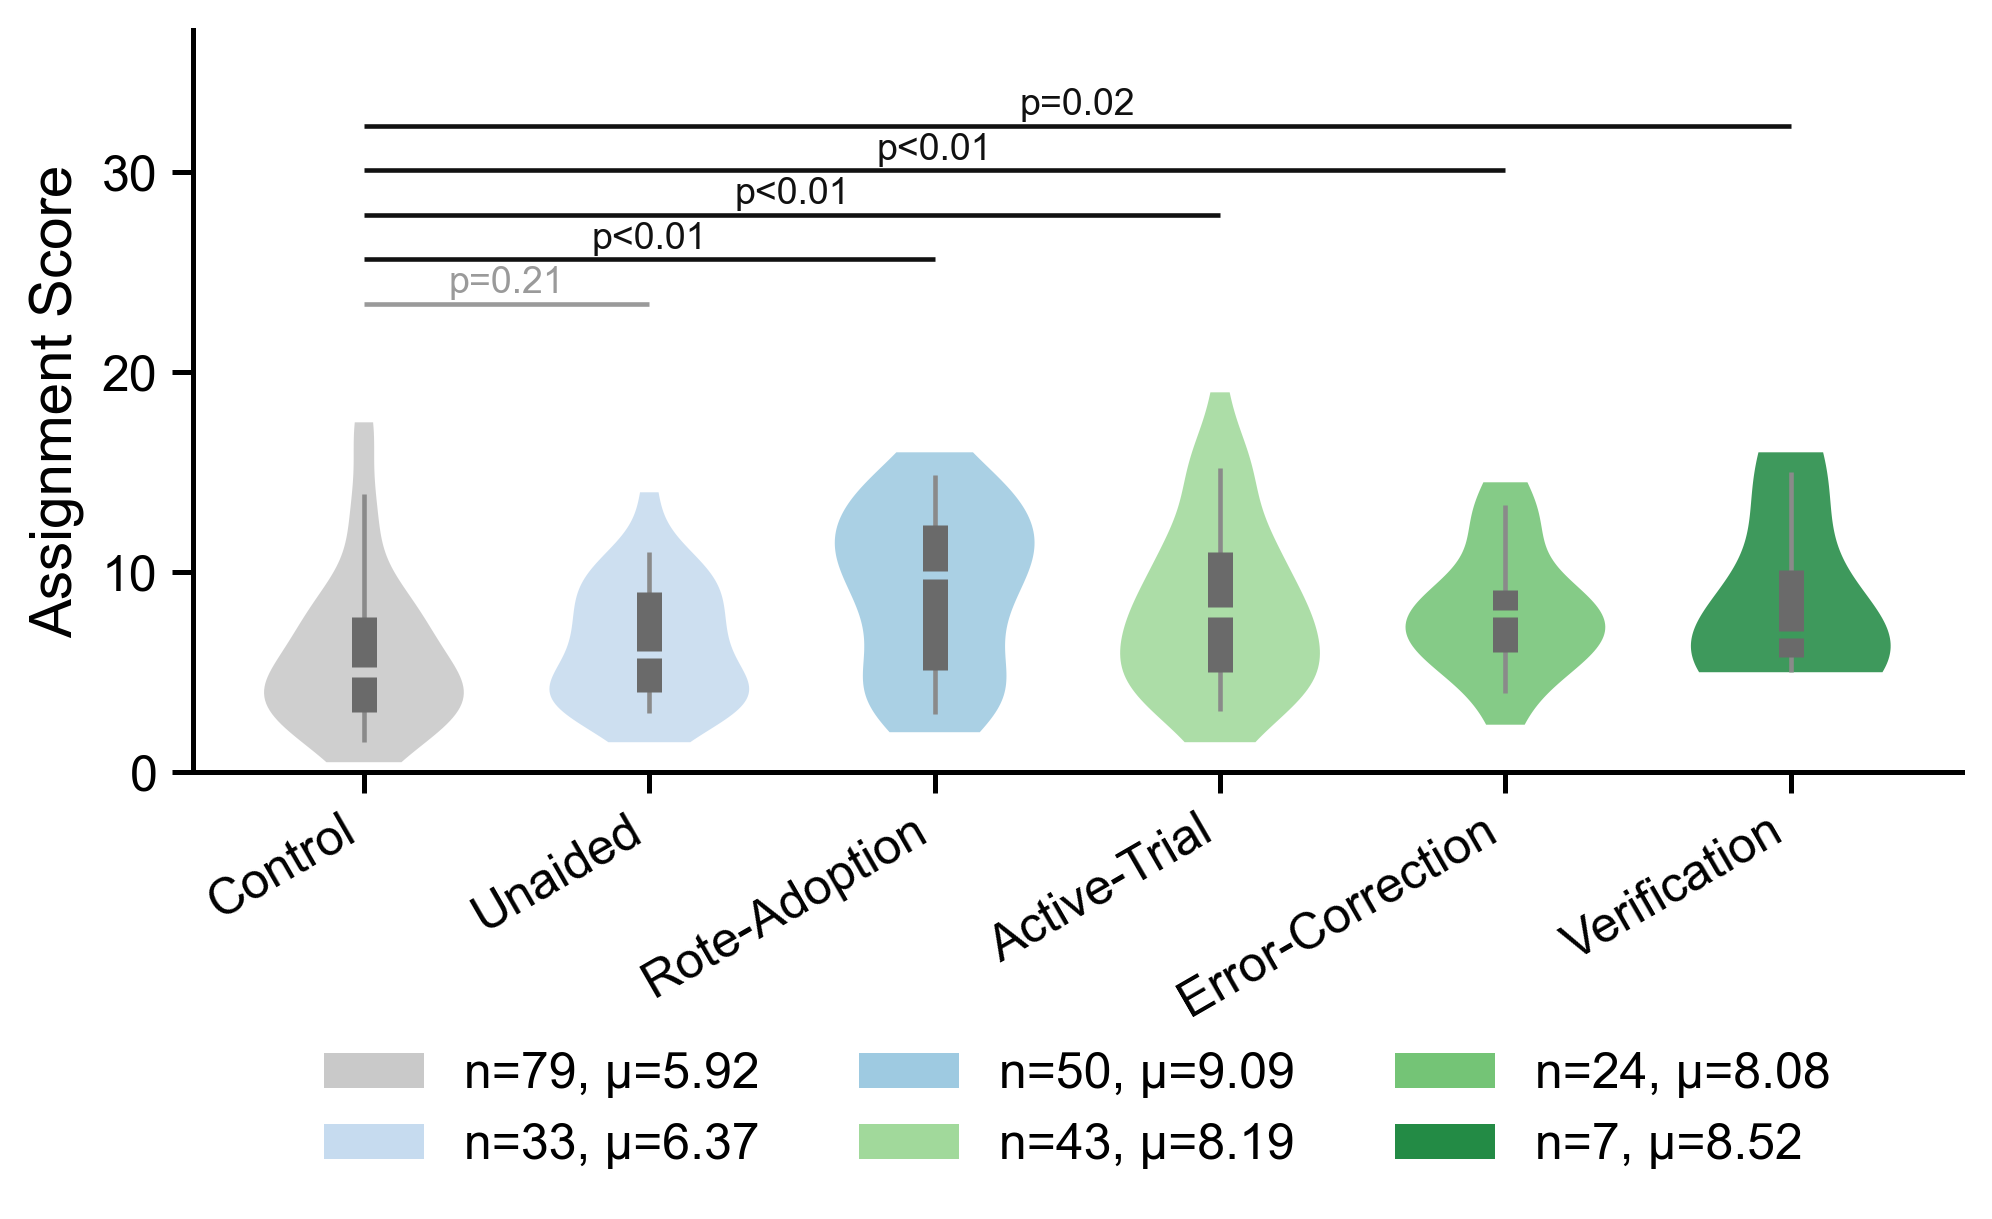

{'python_n': 76,
 'math_n': 237,
 'output_files': [PosixPath('/Users/yjw/Jingwei/llm4edu/GenAI-Learning-Outcomes/figures/a1_hw1_control_vs_exp_behavior.pdf'),
  PosixPath('/Users/yjw/Jingwei/llm4edu/GenAI-Learning-Outcomes/figures/a1_math_hw1_control_vs_exp_behavior.pdf')]}

In [17]:
# Generate the two HW1 behavior-score panels used in the assignment appendix figure.
# The helper prints the group sizes and raw two-sided tests before saving PDFs.
assignment_outputs = assignment_behavior.generate_hw1_behavior_assignment_plots(
    figures_dir=FIGURES_DIR,
    show_figures=SHOW_FIGURES,
)
assignment_outputs


## Assignment Score Inequality

This section checks whether assignment performance differs across student background strata before the later exam-based analysis. The workflow starts from the valid-user roster, merges presurvey background variables, prior-knowledge scores, and assignment scores, then keeps students with nonzero HW1 scores. The plots compare Control and Experimental means within each University Ranking and Prior Knowledge bin, and annotate the treatment-minus-control gap for each bin.


In [18]:
# Build the same analysis table for both courses from the raw roster and score files.
presurvey_hw1 = load_presurvey_data(PRESURVEY_FILE)
python_hw1, math_hw1 = load_valid_users(VALIDUSER_FILE)
py_captest_hw1, math_captest_hw1 = load_capability_scores(CAPTEST_SCORE_FILE)
py_homework_hw1, math_homework_hw1 = load_homework_scores(
    py_scores_file=PYTHON_SCORE_FILE,
    math_scores_file=MATH_SCORE_FILE,
    math_hw1_problems=list(MATH_HW1_PROBLEMS),
    math_hw2_problems=list(MATH_HW2_PROBLEMS),
    math_score_map=dict(MATH_SCORE_MAP),
)

# Presurvey fields provide background strata; capability and homework files
# provide prior-knowledge and assignment outcomes used in the plot.
python_hw1 = merge_presurvey_to_df(python_hw1, presurvey_hw1, course_type="python")
math_hw1 = merge_presurvey_to_df(math_hw1, presurvey_hw1, course_type="math")
python_hw1 = python_hw1.merge(py_captest_hw1, on="username", how="left")
math_hw1 = math_hw1.merge(math_captest_hw1, on="username", how="left")
python_hw1 = python_hw1.merge(py_homework_hw1, on="username", how="left")
math_hw1 = math_hw1.merge(math_homework_hw1, on="username", how="left")

# Covariate preparation normalizes survey encodings, including university rank.
python_hw1 = prepare_covariates(python_hw1, course_type="python")
math_hw1 = prepare_covariates(math_hw1, course_type="math")

# Keep submitted assignments only; zero scores here indicate no usable HW1 outcome.
python_hw1 = python_hw1[python_hw1["hw1_score"] > 0].reset_index(drop=True)
math_hw1 = math_hw1[math_hw1["hw1_score"] > 0].reset_index(drop=True)
print(f"Python HW1 users: {len(python_hw1)}")
print(f"Game Theory HW1 users: {len(math_hw1)}")



Loading presurvey data...
  Loaded presurvey data for 318 users

Loading valid users...
  Loaded 81 Python users and 237 Math users
    Python - Treatment: 54, Control: 27
    Math - Treatment: 158, Control: 79

Loading capability scores...
  Loaded captest for 80 Python users and 237 Math users

Loading homework scores...
  Loaded homework scores for 81 Python users and 237 Math users

Merging presurvey data for python...
  Merged presurvey data for 81 python users

Merging presurvey data for math...
  Merged presurvey data for 237 math users

Preparing covariates for python...
  Major classification: {'CS': 36, 'EE': 16, 'Other Engineering': 15, 'Math & Stat': 6, 'Natural Science': 3, 'Business': 2, 'Humanities': 2, 'Applied Science': 1}
  Prepared covariates for 81 python users

Preparing covariates for math...
  Major classification: {'Humanities': 55, 'CS': 48, 'Other Engineering': 40, 'EE': 35, 'Business': 19, 'Unknown': 15, 'Math & Stat': 14, 'Applied Science': 6, 'Natural Scie


Generating unweighted equity analysis plot for hw1_score...

Mean Statistics:

Python Course:

  :
university_cat  Control_Mean  Control_N  Treatment_Mean  Treatment_N       Gap
          High      3.265306          7       20.666667           13 17.401361
           Low      3.935714          4       11.500000            8  7.564286
           Mid      3.346320         11       16.866359           31 13.520039

  :
capability_cat  Control_Mean  Control_N  Treatment_Mean  Treatment_N       Gap
          High      3.958929          8       14.649660           14 10.690731
           Low      0.714286          3       16.857143            7 16.142857
           Mid      3.549603         12       18.263393           32 14.713790

Math Course:

  :
university_cat  Control_Mean  Control_N  Treatment_Mean  Treatment_N      Gap
          High      6.631250         20        9.303571           35 2.672321
           Low      4.164062         16        7.017045           22 2.852983
          

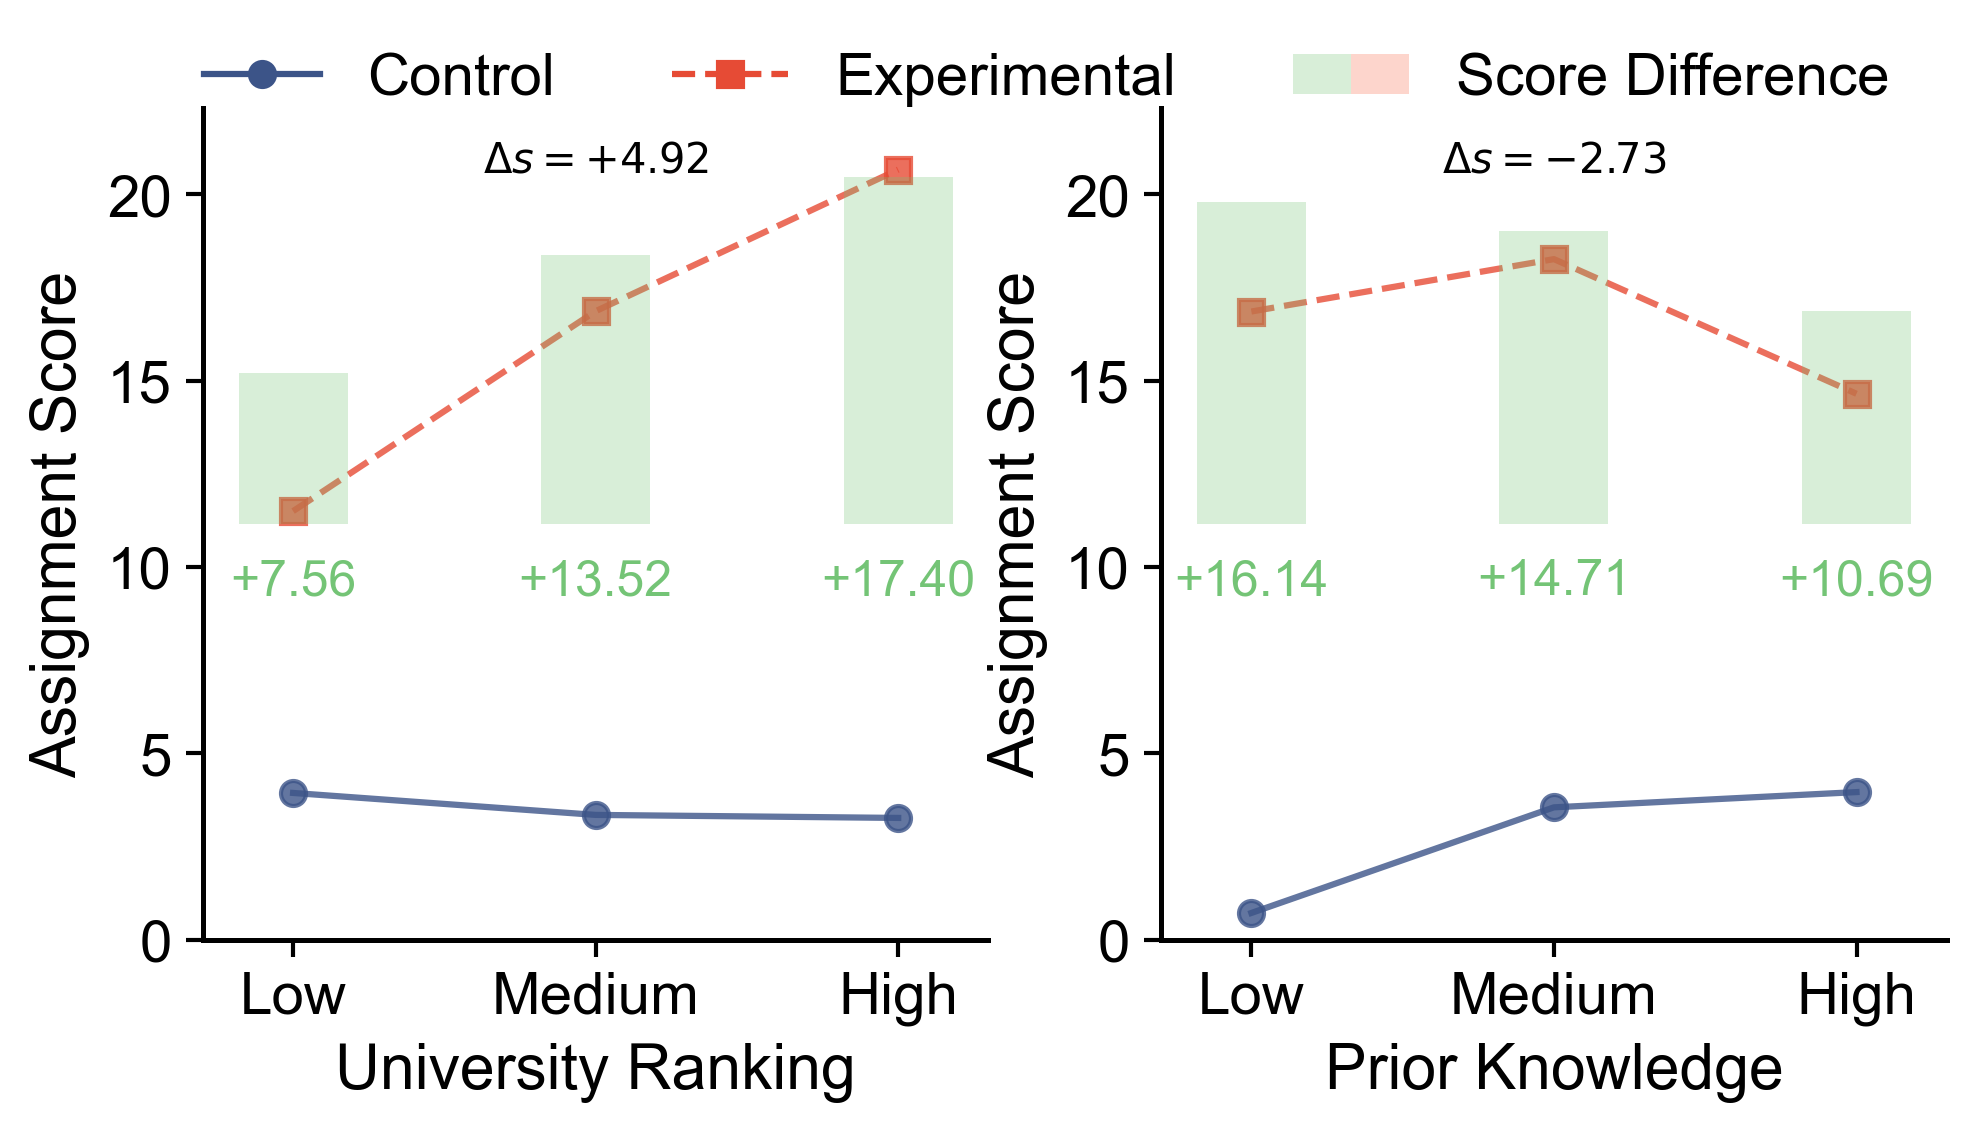


Saved unweighted plot to: inequal_unweighted_hw1_game_theory.pdf


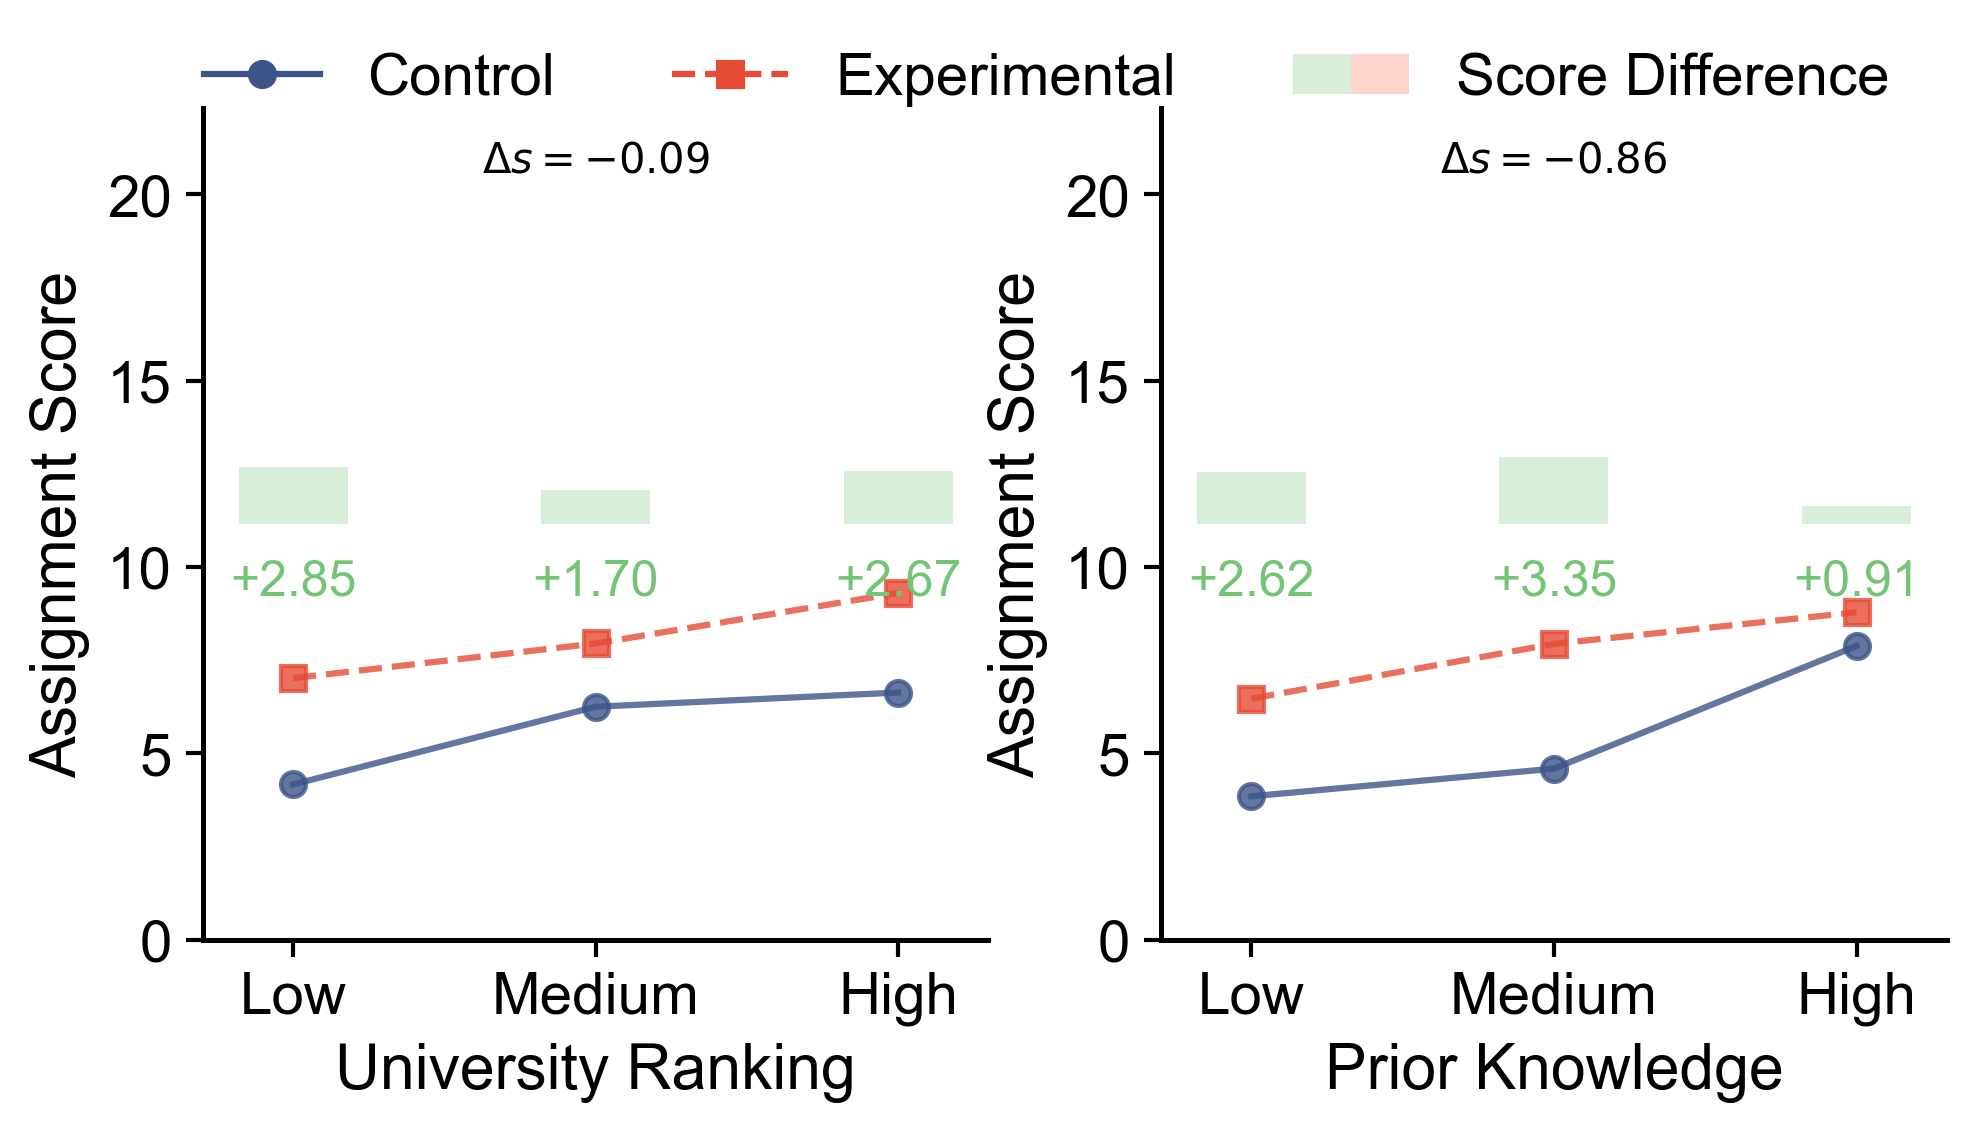

In [19]:
# The plotting function writes one file per course using the original names:
# inequal_unweighted_hw1_python.pdf and inequal_unweighted_hw1_game_theory.pdf.
inequality_plots.plot_equity_hw1(
    python_hw1,
    math_hw1,
    FIGURES_DIR / "inequal_unweighted_hw1.pdf",
    show=SHOW_FIGURES,
)


## Offline LLM Accuracy on Assignment Items

This section evaluates sampled LLM answers to the assignment questions. Python outputs are judged at the problem level using test cases; Game Theory answers are scored at the blank level and weighted by rubric points. Accuracy is then summarized by model and difficulty tier.


Saved plot to: appendix-llm-score-by-difficulty-python.pdf


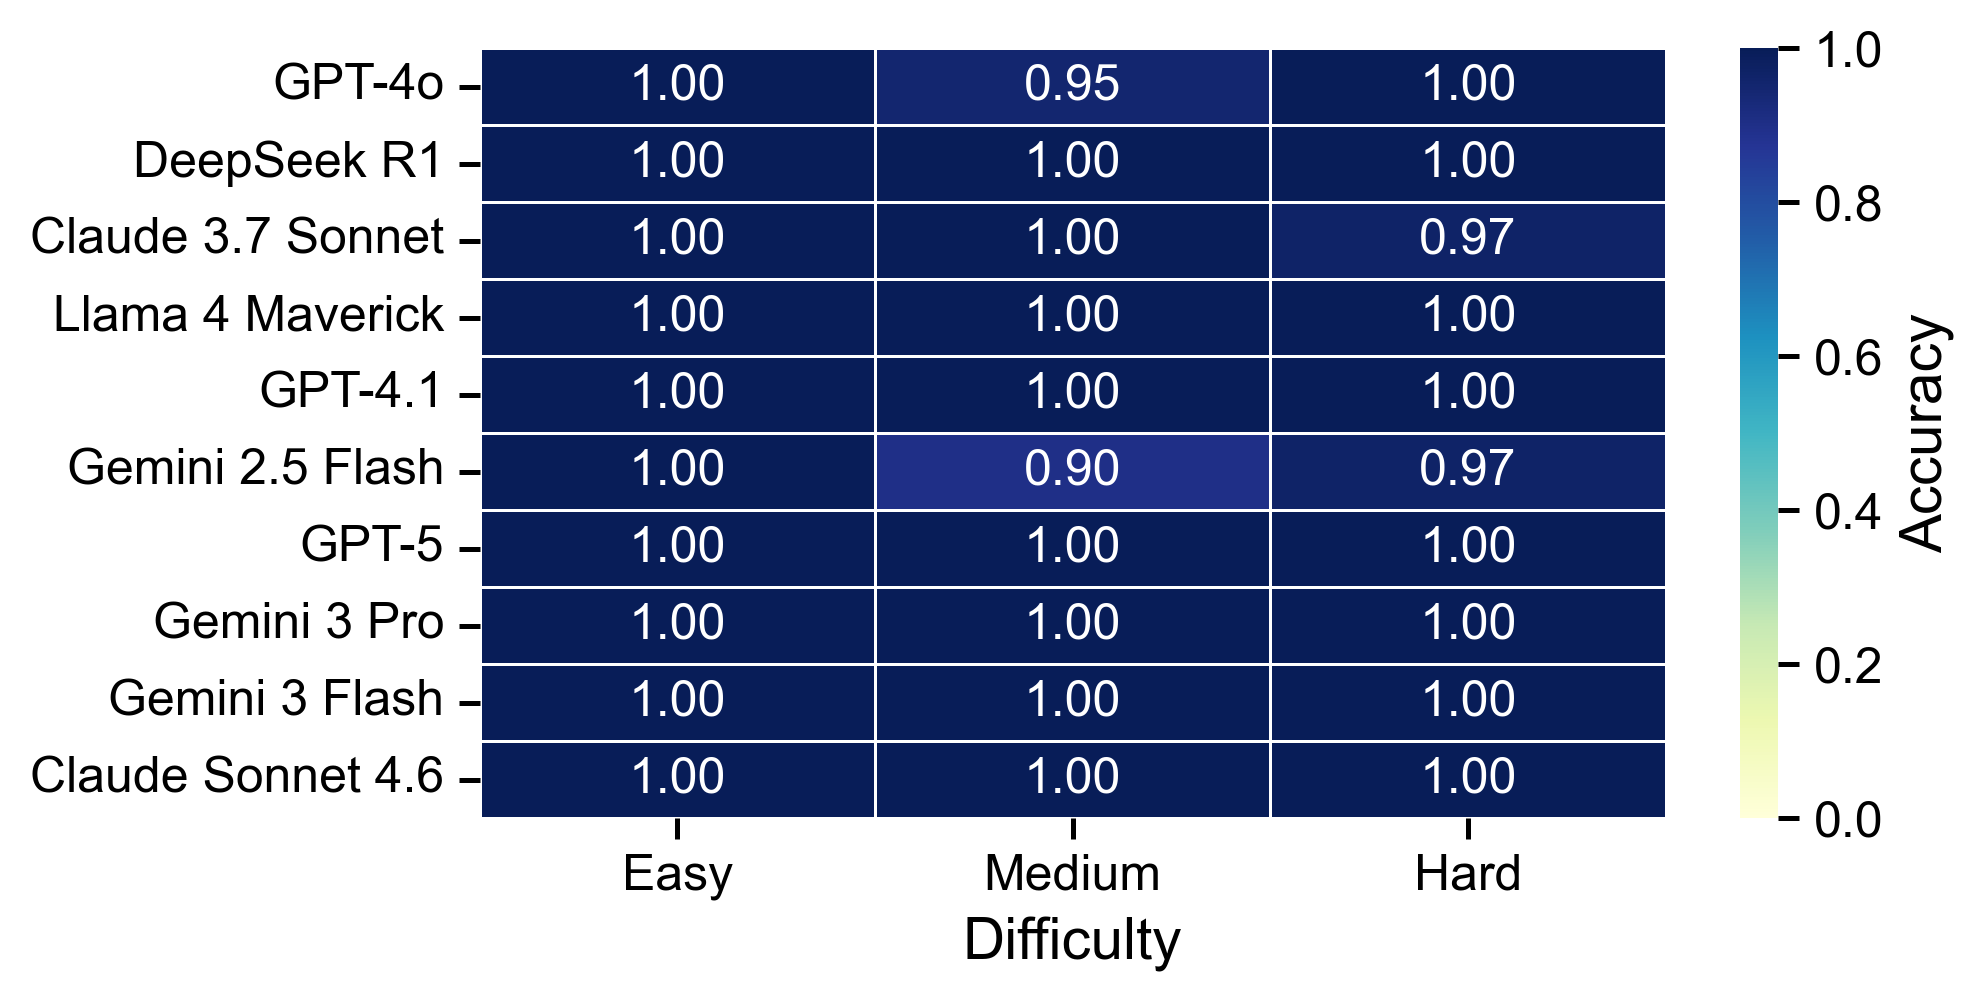

            model difficulty  n_correct  n_total  accuracy
Claude Sonnet 4.6       Easy         30       30     1.000
Claude Sonnet 4.6     Medium         20       20     1.000
Claude Sonnet 4.6       Hard         30       30     1.000
      DeepSeek R1       Easy         30       30     1.000
      DeepSeek R1     Medium         20       20     1.000
      DeepSeek R1       Hard         30       30     1.000
          GPT-4.1       Easy         30       30     1.000
          GPT-4.1     Medium         20       20     1.000
          GPT-4.1       Hard         30       30     1.000
            GPT-5       Easy         30       30     1.000
            GPT-5     Medium         20       20     1.000
            GPT-5       Hard         30       30     1.000
   Gemini 3 Flash       Easy         30       30     1.000
   Gemini 3 Flash     Medium         20       20     1.000
   Gemini 3 Flash       Hard         30       30     1.000
     Gemini 3 Pro       Easy         30       30     1.0

In [20]:
llm_answers_path = _data_path(
    "data/llm/llm_problem_answers_with_eval.json",
    "data/annotation/llm_problem_answers_math_eval.json",
)
difficulty_order = ["Easy", "Medium", "Hard"]

python_runs = llm_eval.load_python_llm_runs(llm_answers_path, prefer_eval=False)
py_llm_df = llm_eval.summarize_python_llm_accuracy_by_difficulty(python_runs)
if py_llm_df.empty:
    print("No valid Python LLM accuracy rows.")
else:
    py_llm_df["model"] = py_llm_df["model"].map(llm_eval.display_model_name)
    py_llm_df["difficulty"] = pd.Categorical(py_llm_df["difficulty"], categories=difficulty_order, ordered=True)
    overall_py = (
        py_llm_df.groupby("model", as_index=False)[["n_correct", "n_total"]]
        .sum()
        .assign(accuracy=lambda d: d["n_correct"] / d["n_total"])
    )
    model_order_py = [m for m in llm_eval.MODEL_ORDER if m in set(overall_py["model"])]
    py_llm_df = py_llm_df.merge(overall_py[["model", "accuracy"]], on="model", how="left", suffixes=("", "_overall"))
    py_llm_df = py_llm_df.sort_values(["accuracy_overall", "model"], ascending=[False, True])
    pivot_py = (
        py_llm_df.pivot_table(index="model", columns="difficulty", values="accuracy", aggfunc="mean")
        .reindex(index=model_order_py, columns=difficulty_order)
    )
    appendix_plots.plot_llm_accuracy_heatmap(
        pivot_py,
        FIGURES_DIR / "appendix-llm-score-by-difficulty-python.pdf",
        show=SHOW_FIGURES,
    )
    print(py_llm_df[["model", "difficulty", "n_correct", "n_total", "accuracy"]].round(3).to_string(index=False))


Saved plot to: appendix-llm-score-by-difficulty-math.pdf


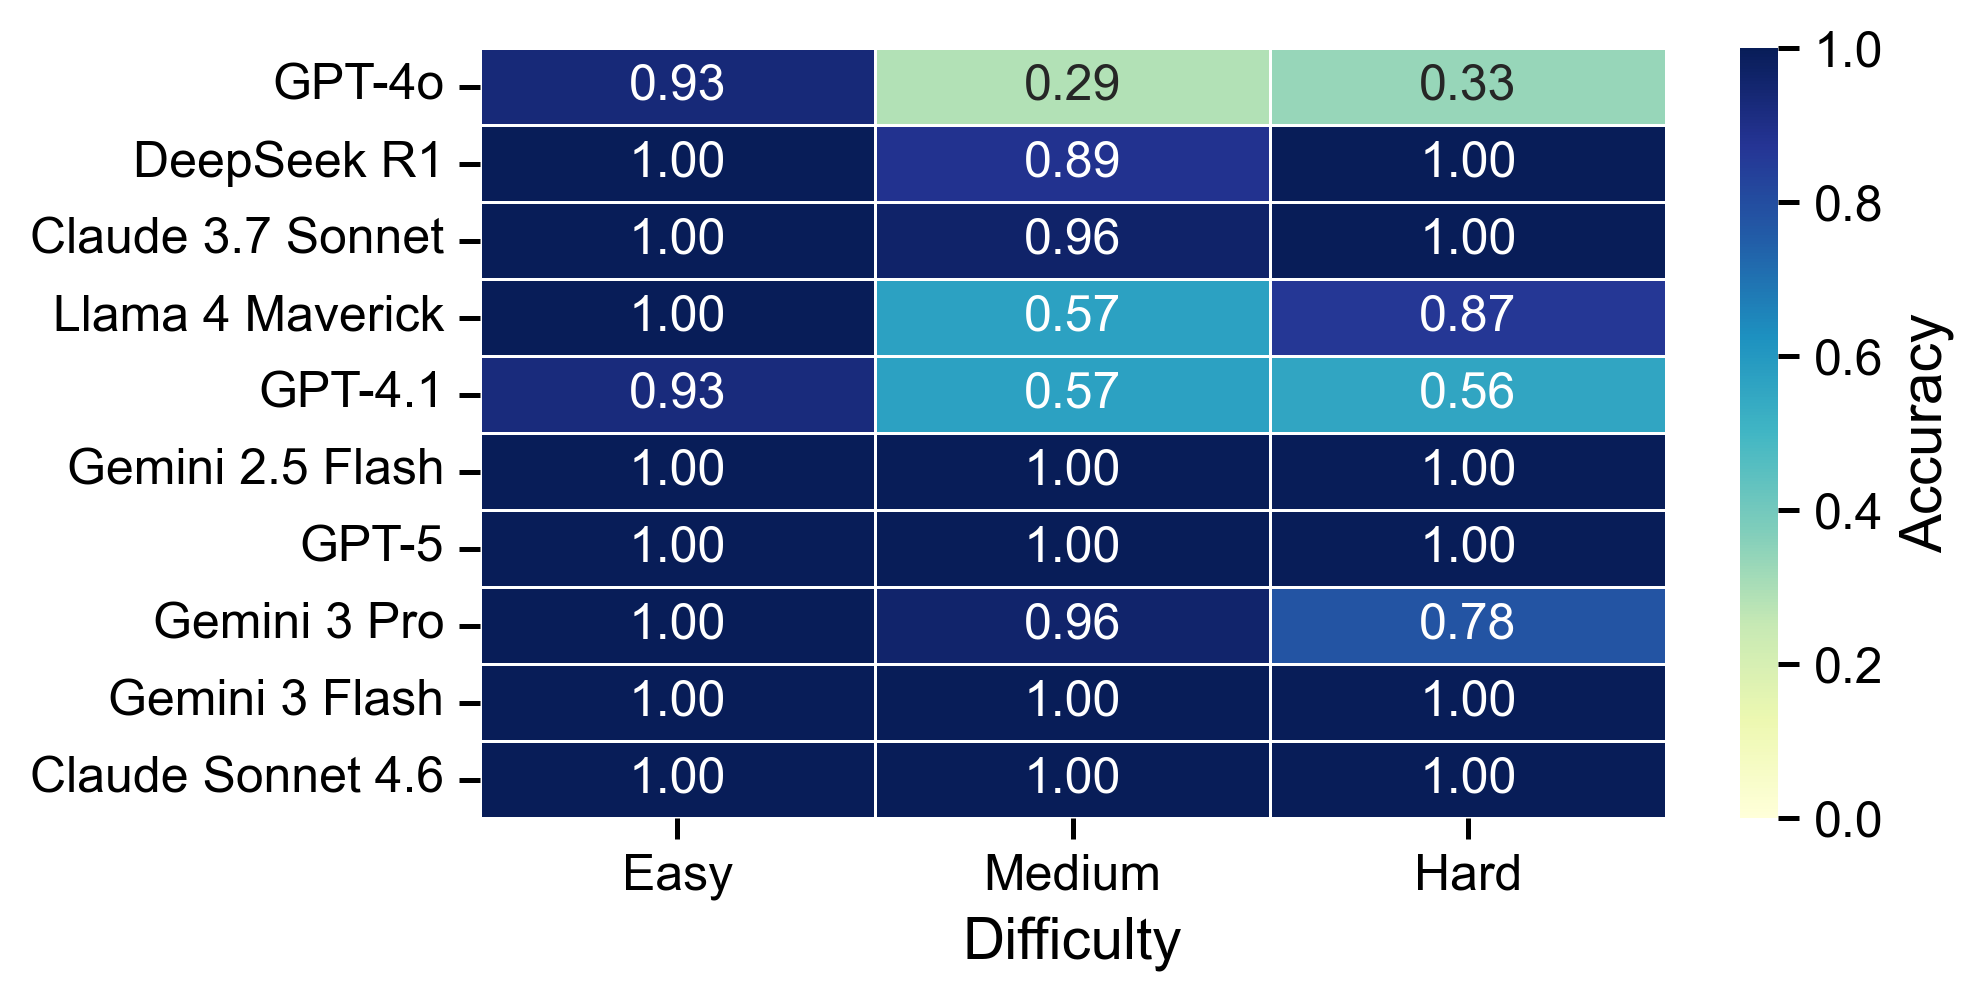

            model difficulty  score_points  total_points  accuracy
Claude Sonnet 4.6       Easy         30.00          30.0     1.000
Claude Sonnet 4.6     Medium         70.00          70.0     1.000
Claude Sonnet 4.6       Hard         90.00          90.0     1.000
            GPT-5       Easy         30.00          30.0     1.000
            GPT-5     Medium         70.00          70.0     1.000
            GPT-5       Hard         90.00          90.0     1.000
 Gemini 2.5 Flash       Easy         30.00          30.0     1.000
 Gemini 2.5 Flash     Medium         70.00          70.0     1.000
 Gemini 2.5 Flash       Hard         90.00          90.0     1.000
   Gemini 3 Flash       Easy         30.00          30.0     1.000
   Gemini 3 Flash     Medium         70.00          70.0     1.000
   Gemini 3 Flash       Hard         90.00          90.0     1.000
Claude 3.7 Sonnet       Easy         30.00          30.0     1.000
Claude 3.7 Sonnet     Medium         67.50          70.0     0

In [21]:
math_reviews = llm_eval.load_math_llm_reviews(llm_answers_path, prefer_eval=True)
blank_points = llm_eval.compute_blank_points_map()
blank_difficulty = llm_eval.assign_difficulty_thresholds(blank_points, easy_max=0.5, medium_max=1.5)
math_llm_df = llm_eval.summarize_llm_scores_by_difficulty(math_reviews, blank_points, blank_difficulty)

if math_llm_df.empty:
    print("No valid Game Theory LLM accuracy rows.")
else:
    math_llm_df["model"] = math_llm_df["model"].map(llm_eval.display_model_name)
    math_llm_df["difficulty"] = pd.Categorical(math_llm_df["difficulty"], categories=difficulty_order, ordered=True)
    overall_math = (
        math_llm_df.groupby("model", as_index=False)[["score_points", "total_points"]]
        .sum()
        .assign(accuracy=lambda d: d["score_points"] / d["total_points"])
    )
    model_order_math = [m for m in llm_eval.MODEL_ORDER if m in set(overall_math["model"])]
    math_llm_df = math_llm_df.merge(overall_math[["model", "accuracy"]], on="model", how="left", suffixes=("", "_overall"))
    math_llm_df = math_llm_df.sort_values(["accuracy_overall", "model"], ascending=[False, True])
    pivot_math = (
        math_llm_df.pivot_table(index="model", columns="difficulty", values="accuracy", aggfunc="mean")
        .reindex(index=model_order_math, columns=difficulty_order)
    )
    appendix_plots.plot_llm_accuracy_heatmap(
        pivot_math,
        FIGURES_DIR / "appendix-llm-score-by-difficulty-math.pdf",
        show=SHOW_FIGURES,
    )
    print(math_llm_df[["model", "difficulty", "score_points", "total_points", "accuracy"]].round(3).to_string(index=False))


## Direct Adoption and In-Task LLM Accuracy

These diagnostics are tied to behavior interpretation rather than the main heterogeneity comparison. Direct adoption measures how often students asked for answer-like help before making a meaningful attempt, and the timing plot shows how quickly that behavior appeared. The accuracy diagnostics summarize whether the assistant's in-task answers were correct and, for Game Theory, whether wrong or later-corrected suggestions aligned with final student answers.


[Appendix][Python] Saved: a1_user_plagiarism_ratio.pdf


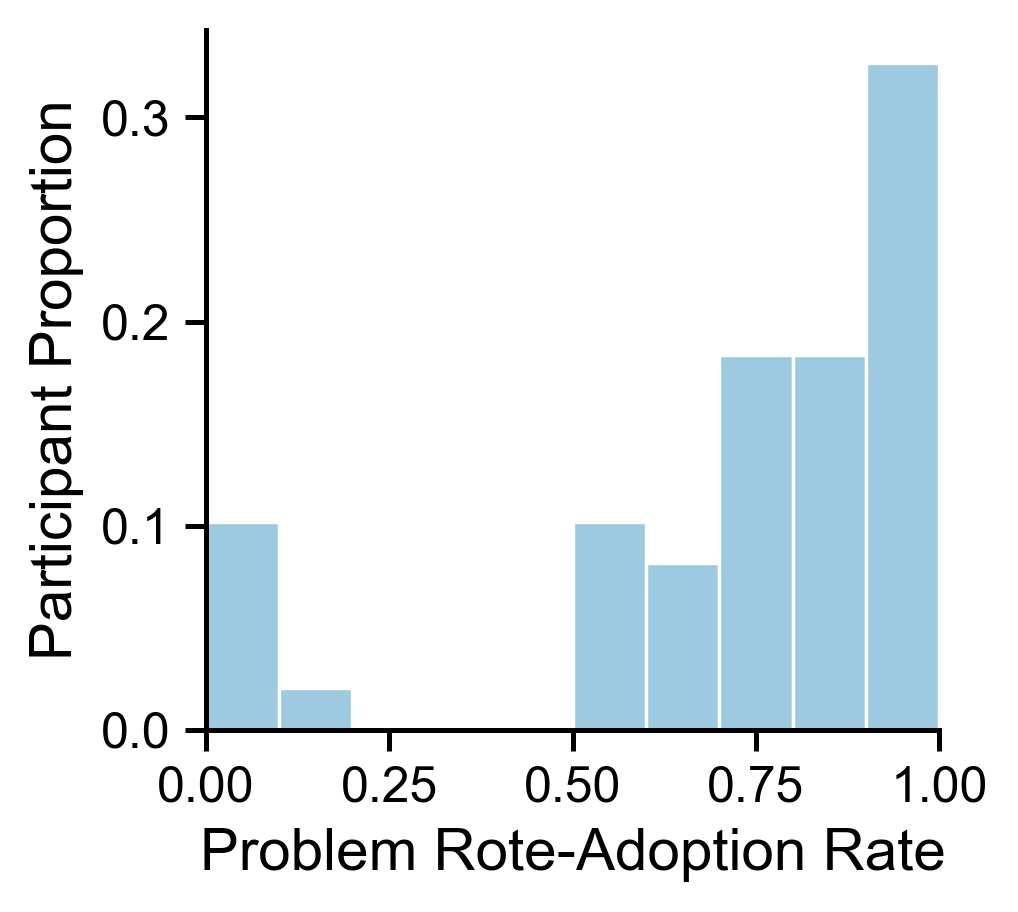

[Appendix][Python] Saved: a1_problem_plagiarism_ratio.pdf


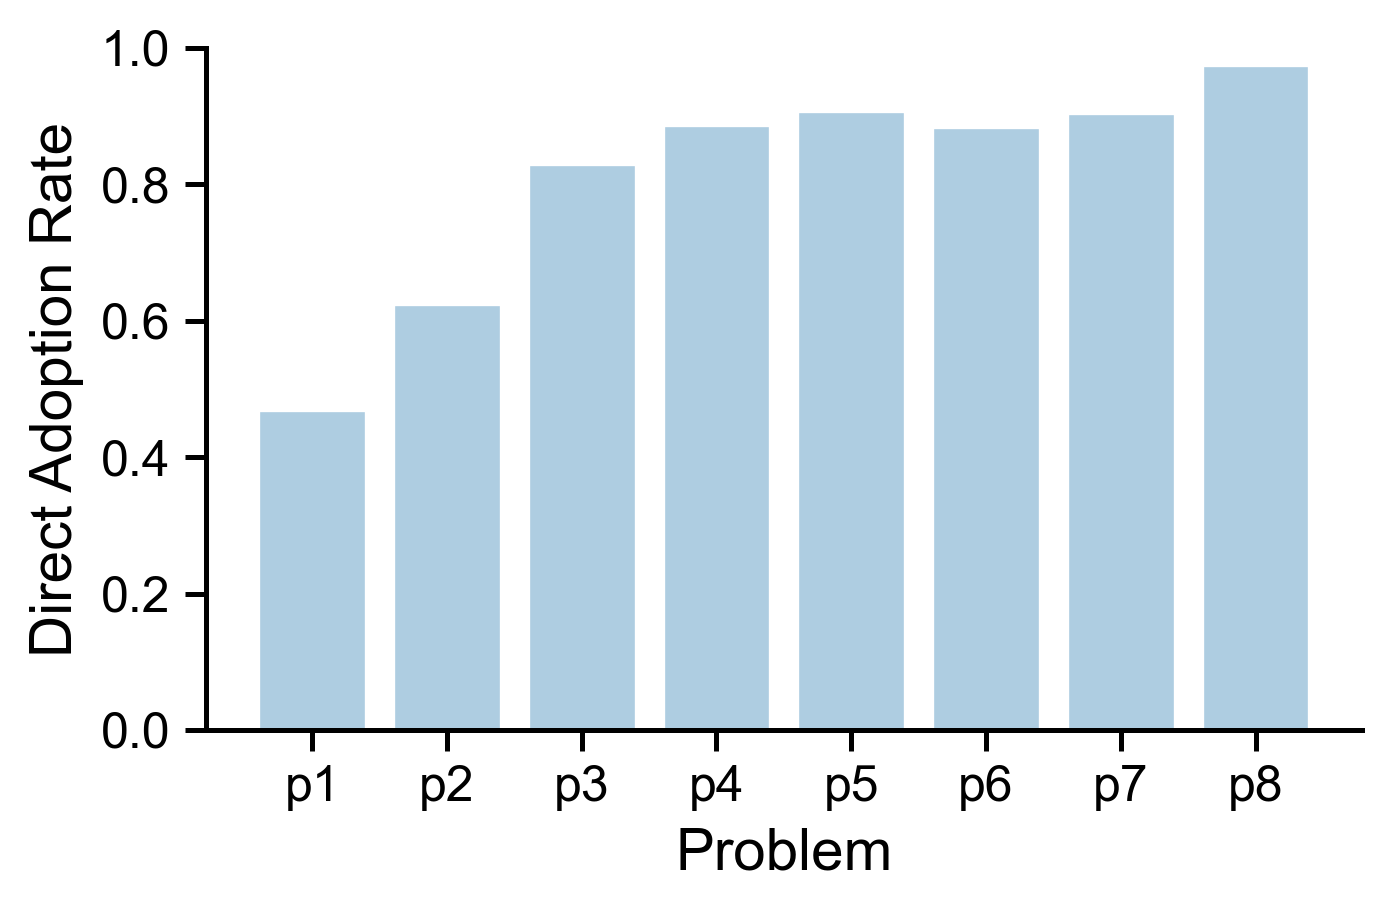

[Appendix][Python] Saved: a1_first_no_tried_copy_time_cdf.pdf


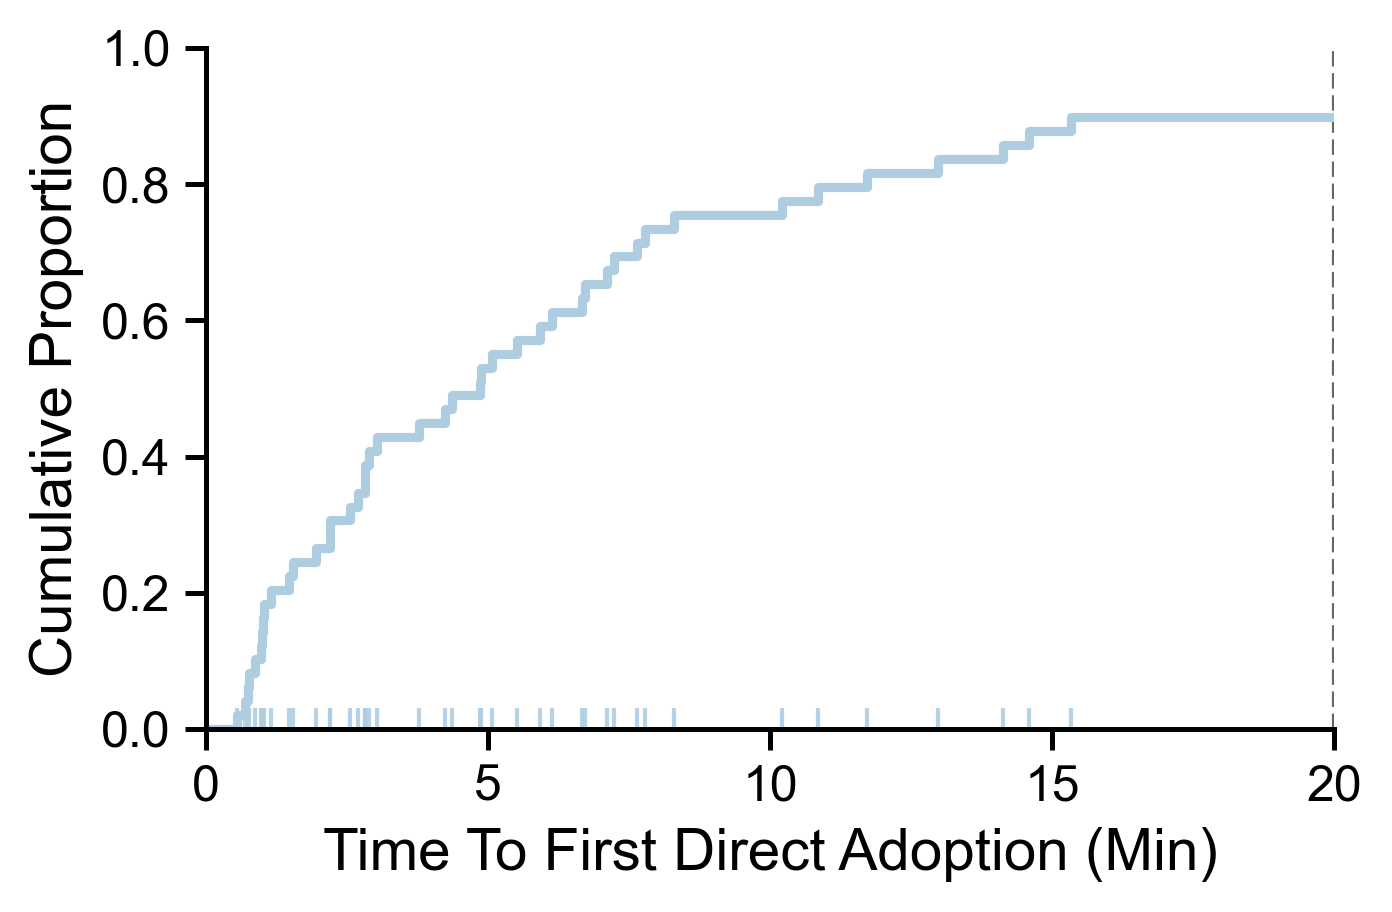

[Appendix][Python] Saved: a1_py_llm_accuracy_by_difficulty.pdf


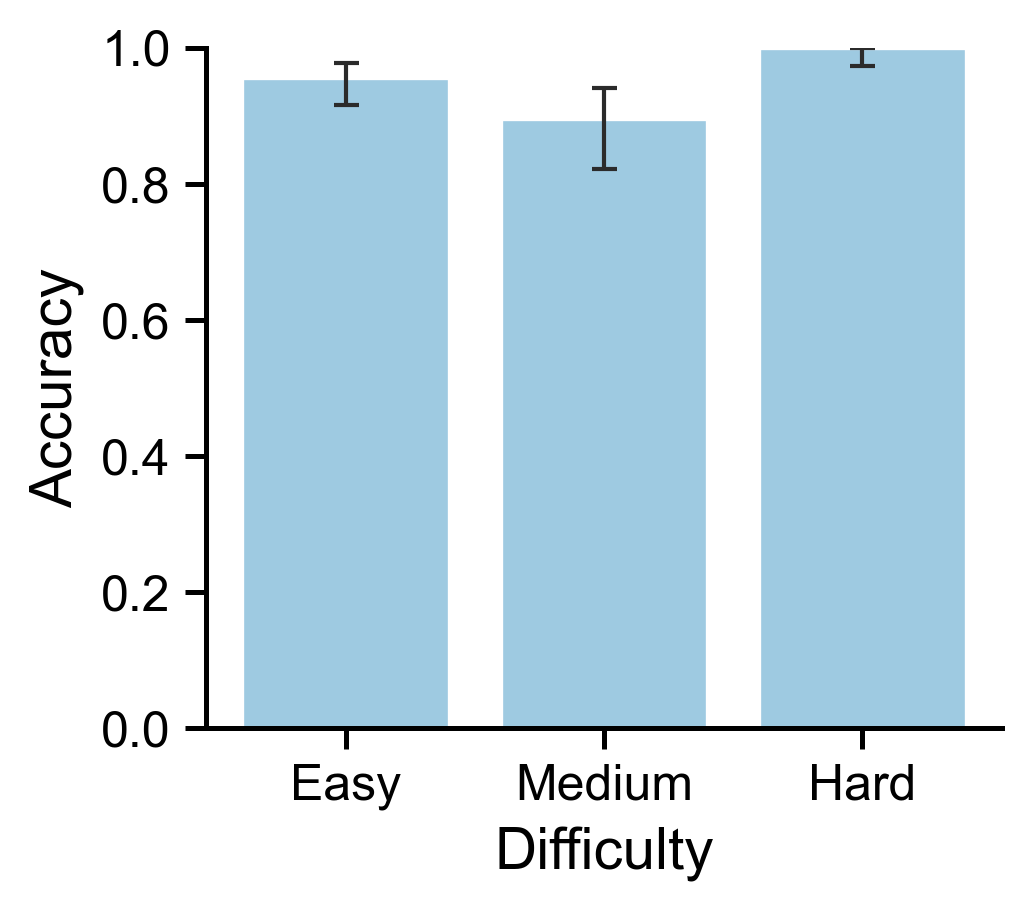


Loading valid users...
  Loaded 81 Python users and 237 Math users
    Python - Treatment: 54, Control: 27
    Math - Treatment: 158, Control: 79
[Appendix][Math] Saved: a1_math_user_plagiarism_ratio.pdf


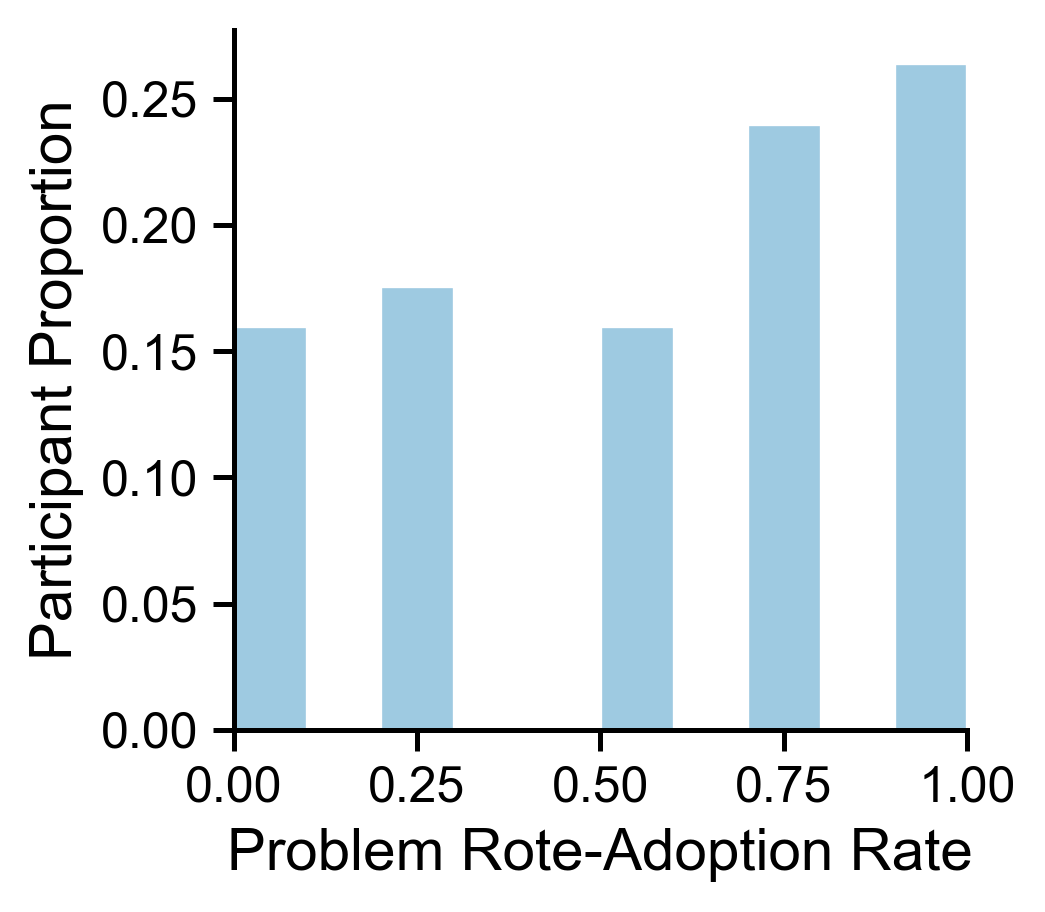

[Appendix][Math] Saved: a1_math_problem_plagiarism_ratio.pdf


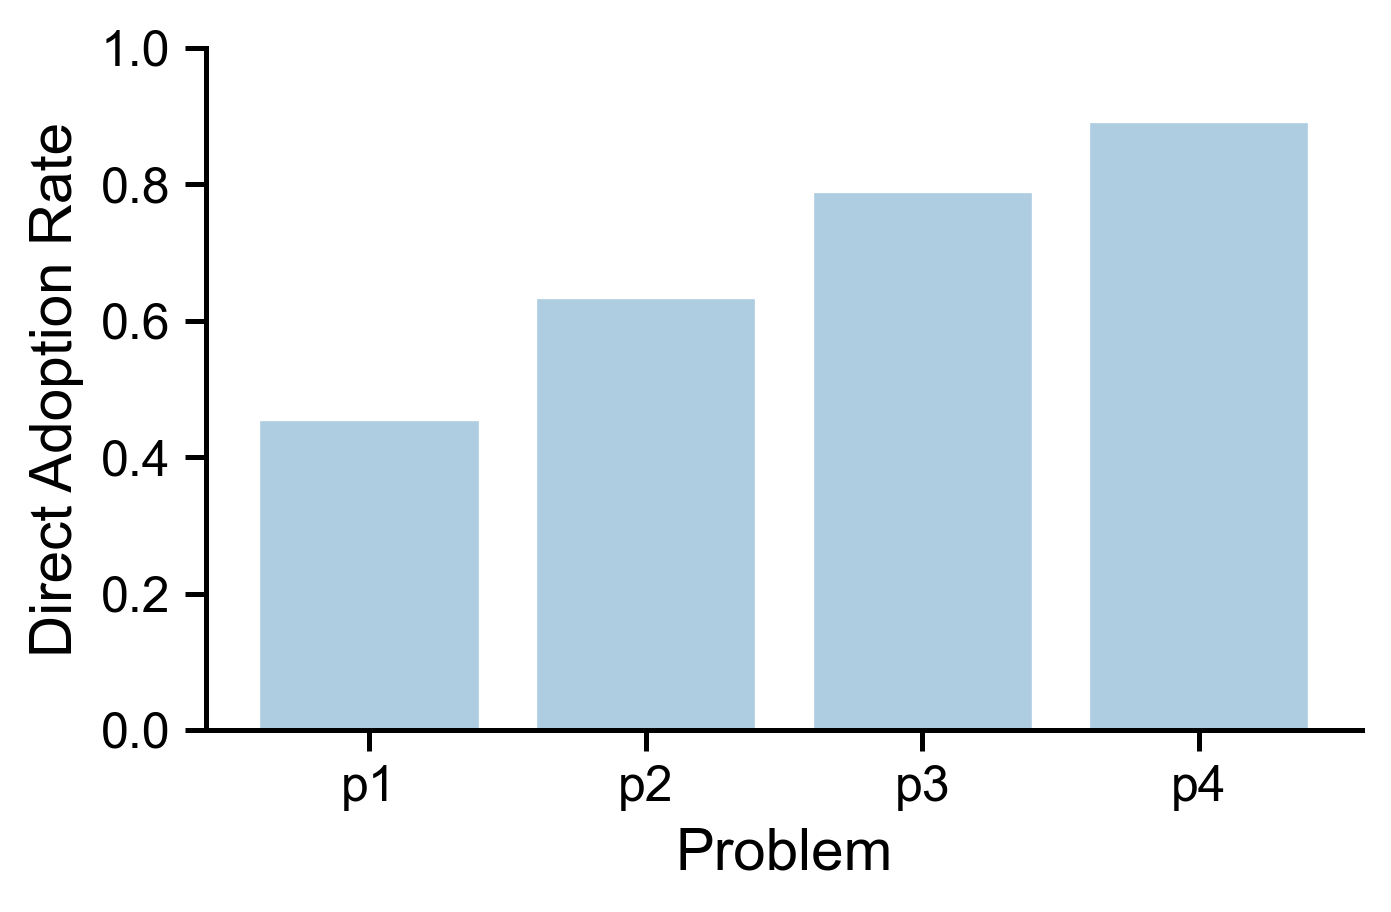

[Appendix][Math] Saved: a1_math_first_no_tried_copy_time_cdf.pdf


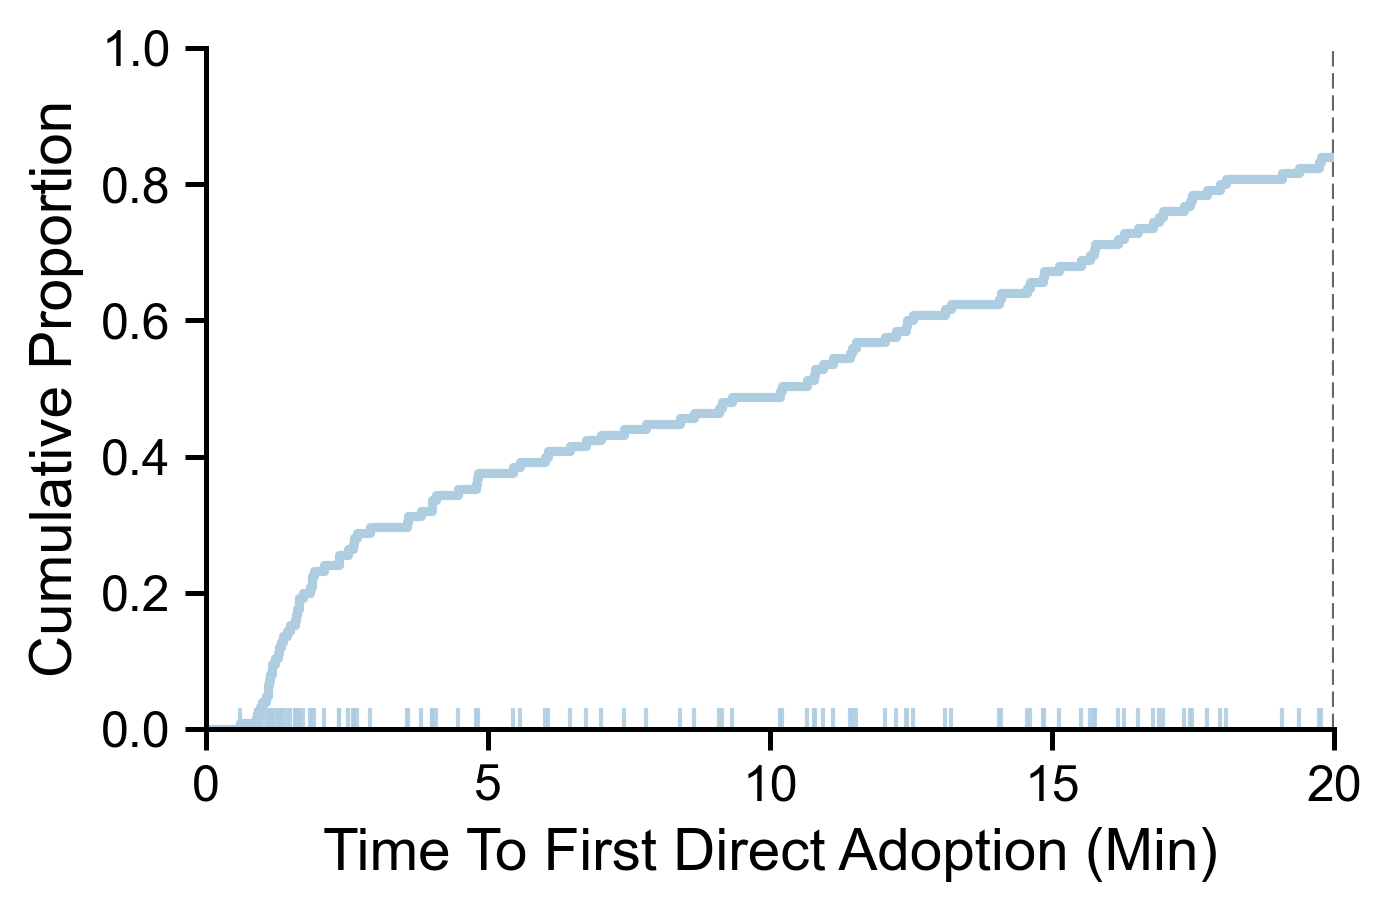

[Appendix][Math] Saved: a1_math_llm_accuracy_by_difficulty.pdf


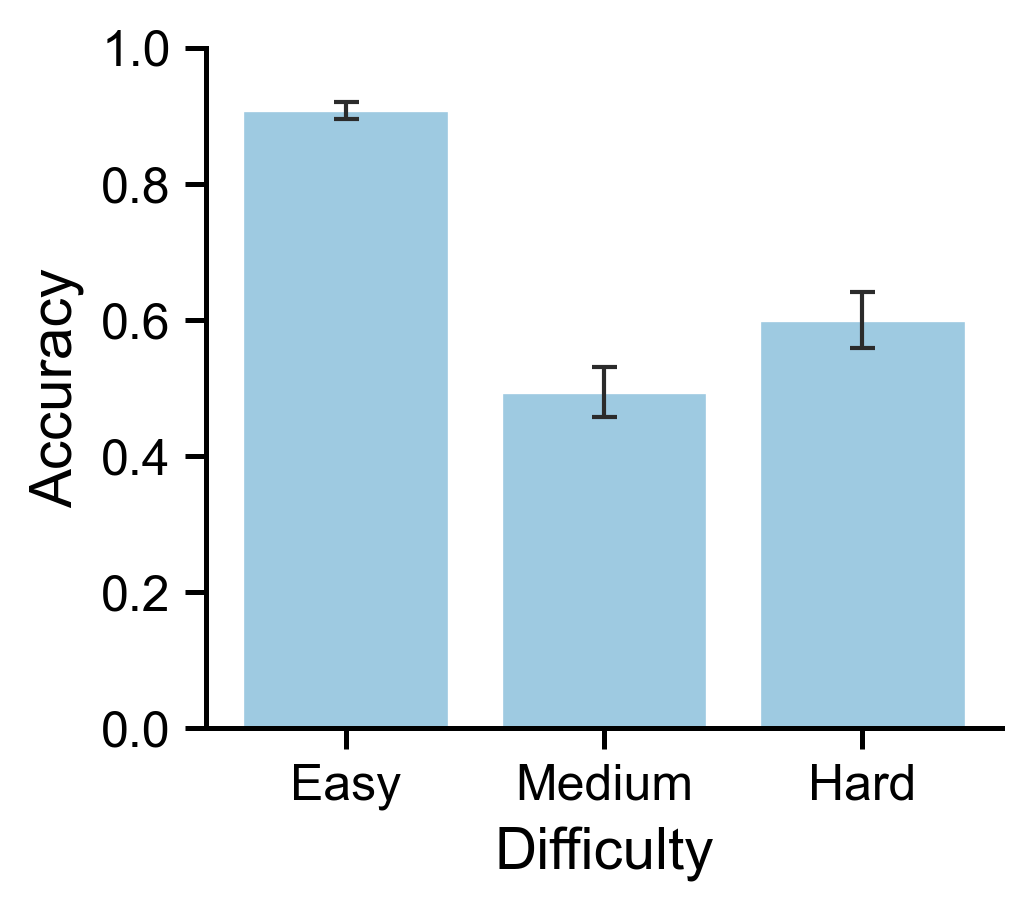

[Appendix][Math] Saved: a1_math_llm_wrong_outcome_by_difficulty.pdf


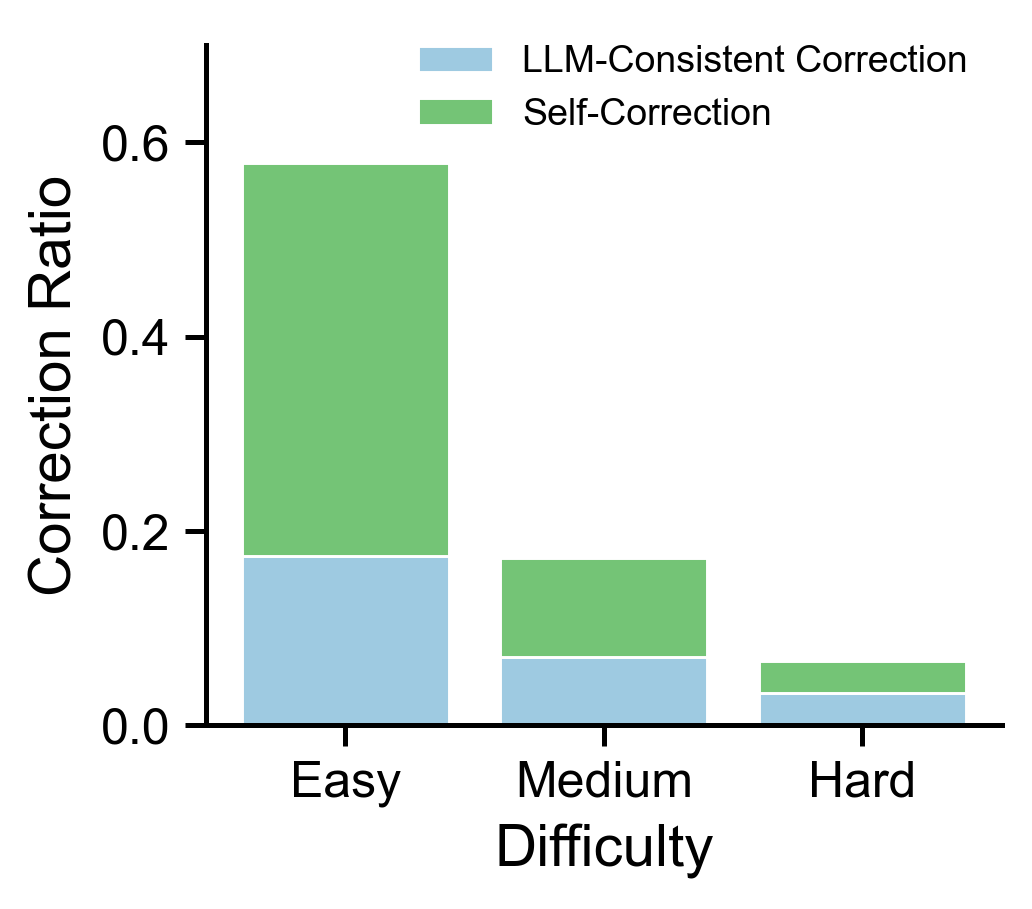

[Appendix][Math] Saved: a1_math_llm_correct_not_adopted_by_difficulty.pdf


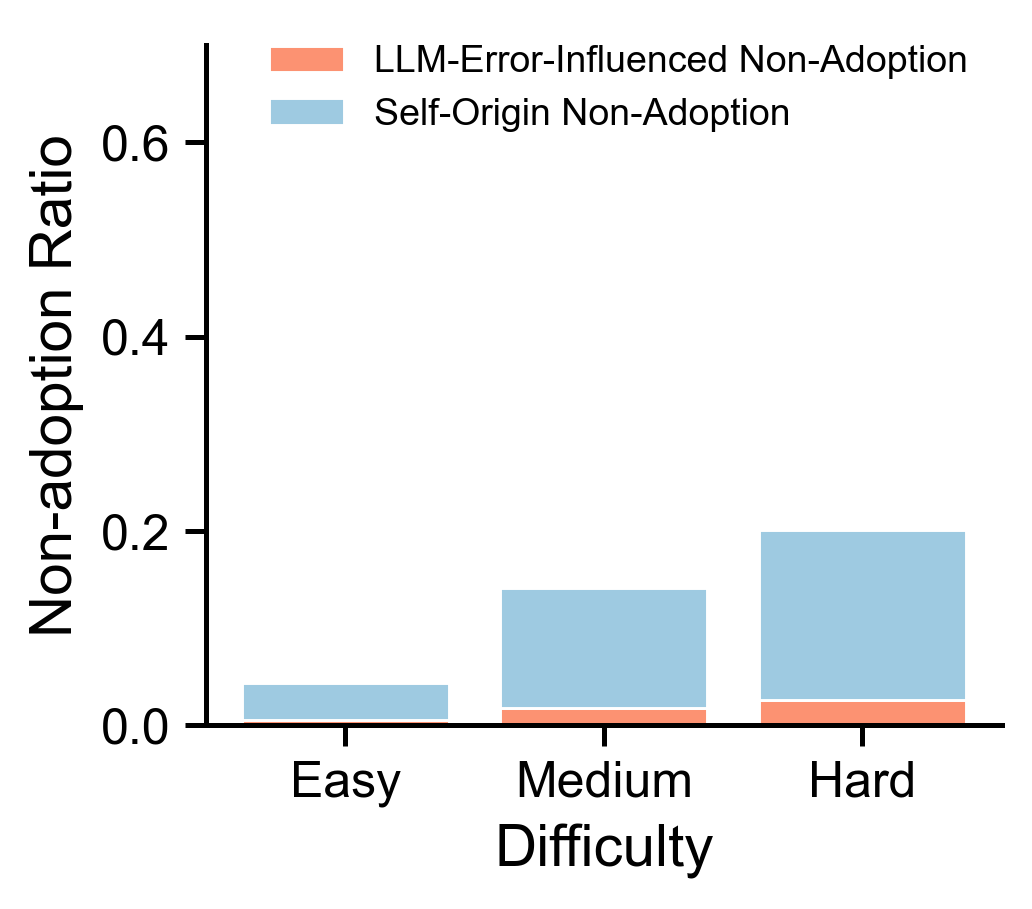

In [22]:
# This wrapper writes the direct-adoption figures for Python and Game Theory,
# plus in-task LLM accuracy/correction diagnostics by difficulty.
adoption.generate_a1_behavior_diagnostics(
    figures_dir=FIGURES_DIR,
    show_figures=SHOW_FIGURES,
)


## Outputs

The main generated appendix outputs are:

- `appendix-test-quality-likert-python-math.pdf`
- `appendix-feature-importance-combined.pdf`
- `appendix-feature-direction-python-math.pdf`
- `a1_hw1_control_vs_exp_behavior.pdf`
- `a1_math_hw1_control_vs_exp_behavior.pdf`
- `inequal_unweighted_hw1_python.pdf`
- `inequal_unweighted_hw1_game_theory.pdf`
- `appendix-llm-score-by-difficulty-python.pdf`
- `appendix-llm-score-by-difficulty-math.pdf`
- `a1_*_plagiarism_ratio.pdf` and `a1_*_first_no_tried_copy_time_cdf.pdf`
- `a1_py_llm_accuracy_by_difficulty.pdf`
- `a1_math_llm_accuracy_by_difficulty.pdf`
- `a1_math_llm_wrong_outcome_by_difficulty.pdf`
- `a1_math_llm_correct_not_adopted_by_difficulty.pdf`
